<center><span style="color:#27A3F5;font-size:26px;font-weight:700">Rent price prediction in Berlin</span></center>

The goal of this project is to create the most suitable ML model to predict rent prices (Kaltmiete) in Berlin. Since Warmmiete (rent that includes other costs like electricity, heating, etc) isn’t available in all listings, it was more suitable to use Kaltmiete instead. In this case, the best place to find the data for our dataset is real estate and apartment-search websites like Immowelt, WG-Gesucht, Immosuchmaschine, Kleineanzeigen, etc. For this project, I decided to use only Immowelt, since it included more data overall per listing, therefore more features can be included in the dataset. Also, it has a lot of new listings per day, so it is sufficient to build a proper dataset with enough samples if we gather data regularly.

<span style="color:#609926;font-size:20px;font-weight:500">Data Cleaning & Preparation</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 1: Handling missing values</span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/immowelt_listings.csv')
df.head(5)

,listing_url,cold_rent,warm_rent,deposit,area,rooms,floor,free_from,location,has_balkon,...,badewanne,dusche,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,number_of_images_posted,scraped_at
0,https://www.immowelt.de/expose/f6e9dd76-dbe1-4...,"1,499 €",NaN,4500,"58,3 m²",2 Zimmer,5. Geschoss,15.02.2026,"Friedenauer Höhe 23a, Friedenau, Berlin (12159)",True,...,NaN,True,"fliesen, parkett",Fernwärme,Fußbodenheizung,Erstbezug,2025,True,12.0,12/28/2025 21:25
1,https://www.immowelt.de/expose/56cf72dd-00ea-4...,"1,178 €",1.350 € Warmmiete,3534,"45,7 m²",2 Zimmer,4. Geschoss,01.03.2026,"Spreestraße, Köpenick, Berlin (12555)",NaN,...,NaN,True,parkett,NaN,Etagenheizung,NaN,2025,True,12.0,12/28/2025 21:26
2,https://www.immowelt.de/expose/591c45d0-01dd-4...,"5,130 €",6.130 € Warmmiete,15390,270 m²,3 Zimmer,3. Geschoss,sofort,"Zeughofstrasse 20, Kreuzberg, Berlin (10799)",NaN,...,NaN,NaN,NaN,Fernwärme,Zentralheizung,"Altbau (bis 1945), neuwertig",1902,True,9.0,12/28/2025 21:26
3,https://www.immowelt.de/expose/8e225383-b57c-4...,360 €,475 € Warmmiete,1080,93 m²,1 Zimmer,2. Geschoss,29.12.2025,"Bahnhofstraße, Köpenick, Berlin (12555)",NaN,...,True,True,holzdielen,NaN,NaN,NaN,2025,True,9.0,12/28/2025 21:26
4,https://www.immowelt.de/expose/03a3d0b6-9fab-4...,"1,399 €",1.649 € Warmmiete,NaN,"65,8 m²",2 Zimmer,1. Geschoss,01.02.2026,"Friedenauer Höhe 16, Friedenau, Berlin (12159)",True,...,NaN,True,NaN,Fernwärme,Fußbodenheizung,neuwertig,2024,True,20.0,12/28/2025 21:27


In [3]:
df.shape

(22687, 27)

<span style="font-weight:500">
22687 samples and 27 features is a pretty good dataset
</span>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22687 entries, 0 to 22686
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   listing_url              22687 non-null  object 
 1   cold_rent                22289 non-null  object 
 2   warm_rent                12409 non-null  object 
 3   deposit                  8311 non-null   object 
 4   area                     21656 non-null  object 
 5   rooms                    21679 non-null  object 
 6   floor                    18815 non-null  object 
 7   free_from                13097 non-null  object 
 8   location                 21515 non-null  object 
 9   has_balkon               10969 non-null  object 
 10  has_terrasse             5991 non-null   object 
 11  has_garten               2138 non-null   object 
 12  elevator                 9914 non-null   object 
 13  parking                  3460 non-null   object 
 14  keller                

In [5]:
df.isnull().sum()

listing_url                    0
cold_rent                    398
warm_rent                  10278
deposit                    14376
area                        1031
rooms                       1008
floor                       3872
free_from                   9590
location                    1172
has_balkon                 11718
has_terrasse               16696
has_garten                 20549
elevator                   12773
parking                    19227
keller                     12509
barrierefrei               20038
einbaukueche               10055
badewanne                  17399
dusche                     17075
flooring_type              14892
energy_source              13343
heating_type               10299
property_condition         13652
year_built                 11560
schufa_check                   0
number_of_images_posted     8418
scraped_at                     0
dtype: int64

<span style="font-weight:500">
Only 3 features don't have any missing values: 'listing_url' which sort of serves as an identifier, schufa_check which aws already taken care of by the scraper, it was set to false if it was not found and 'scrapet_at' which is the time of scraping, a metadata provided by the scraper. We shouldn't be concerned with most of them having so many null values because they are boolean features and we can easily replace null with False.
</span>

In [6]:
# We might start with cleaning by renaming the german features into english to be consistent.
df = df.rename(columns={'keller': 'has_basement','barrierefrei':'is_barrier-free','einbaukueche':'has_built-in_kitchen','badewanne':'has_bathtub',
                       'dusche':'has_shower'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22687 entries, 0 to 22686
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   listing_url              22687 non-null  object 
 1   cold_rent                22289 non-null  object 
 2   warm_rent                12409 non-null  object 
 3   deposit                  8311 non-null   object 
 4   area                     21656 non-null  object 
 5   rooms                    21679 non-null  object 
 6   floor                    18815 non-null  object 
 7   free_from                13097 non-null  object 
 8   location                 21515 non-null  object 
 9   has_balkon               10969 non-null  object 
 10  has_terrasse             5991 non-null   object 
 11  has_garten               2138 non-null   object 
 12  elevator                 9914 non-null   object 
 13  parking                  3460 non-null   object 
 14  has_basement          

<span style="font-weight:500">
We will assume that all the listings have advertised everything in their listing. Meaning if they haven't mentioned having an elevator in the advertisement, then the scraper has nothing to scrape and has returned null. For that we assume that the apartment does not have an elevator and replace 'null' with 'False'. 
We do this for all boolean features.
</span>

In [7]:
cols = [
    'has_balkon','has_terrasse','has_garten','elevator','parking',
    'has_basement','is_barrier-free','has_built-in_kitchen',
    'has_bathtub','has_shower'
]

df[cols] = df[cols].astype("boolean").fillna(False)

In [8]:
df.isnull().sum()

listing_url                    0
cold_rent                    398
warm_rent                  10278
deposit                    14376
area                        1031
rooms                       1008
floor                       3872
free_from                   9590
location                    1172
has_balkon                     0
has_terrasse                   0
has_garten                     0
elevator                       0
parking                        0
has_basement                   0
is_barrier-free                0
has_built-in_kitchen           0
has_bathtub                    0
has_shower                     0
flooring_type              14892
energy_source              13343
heating_type               10299
property_condition         13652
year_built                 11560
schufa_check                   0
number_of_images_posted     8418
scraped_at                     0
dtype: int64

<span style="font-weight:500">
Now we are left with 14 features to clean. We will start with the features that are easy to fix, like 'number_of_images_posted' and features that have very few missing areas, like 'cold_rent'. For the 'cold_rent', which is the predicted feature, luckily we only have 324 missing values, which is nothing compared to the number of samples our dataset has. We can either drop them or use an unsupervised learning algorithm to estimate those values.
</span>

In [9]:
# For that we have to check the samples with the missing values to see if they are good samples or not.
df[df.cold_rent.isnull()].sample(15)

,listing_url,cold_rent,warm_rent,deposit,area,rooms,floor,free_from,location,has_balkon,...,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,number_of_images_posted,scraped_at
17975,https://www.immowelt.de/expose/43778d73-a328-4...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,False,NaN,2026-01-26 14:10:51
20353,https://www.immowelt.de/expose/f1f7f0ad-3e50-4...,NaN,NaN,NaN,92 m²,3 Zimmer,1. Geschoss,NaN,"Moabit, Berlin (10559)",True,...,False,True,"holzdielen, parkett",NaN,Etagenheizung,NaN,NaN,True,NaN,2026-01-30 20:12:46
17960,https://www.immowelt.de/expose/e8e7bb91-1181-4...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,False,NaN,2026-01-26 14:09:50
4497,https://www.immowelt.de/projekte/expose/k2mv83...,NaN,NaN,NaN,60 bis 142 m²,2 bis 4 Zimmer,Bezugsbereit 01.03.2025,NaN,"Friedenauer Höhe 19A, Mariendorf, Berlin (12159)",True,...,False,False,NaN,Fernwärme,NaN,NaN,NaN,False,13.0,2026-01-11 13:42:45
4629,https://www.immowelt.de/projekte/expose/k2mv83...,NaN,NaN,NaN,60 bis 142 m²,2 bis 4 Zimmer,Bezugsbereit 01.03.2025,NaN,"Friedenauer Höhe 19A, Mariendorf, Berlin (12159)",True,...,False,False,NaN,Fernwärme,NaN,NaN,NaN,False,13.0,2026-01-11 14:10:52
14459,https://www.immowelt.de/projekte/expose/k2n6a3...,NaN,NaN,NaN,28 bis 77 m²,1 bis 3 Zimmer,NaN,NaN,"Buschkurgallee 64, Britz, Berlin (12359)",True,...,False,False,NaN,NaN,NaN,NaN,NaN,False,15.0,2026-01-23 10:40:08
8657,https://www.immowelt.de/projekte/expose/k2vj93...,NaN,NaN,NaN,37 bis 130 m²,1 bis 3 Zimmer,Bezugsbereit 2025,NaN,"Wöhlertstraße 21, Mitte, Berlin (10115)",False,...,False,False,NaN,Fernwärme,NaN,NaN,NaN,False,13.0,2026-01-16 21:41:36
6246,https://www.immowelt.de/expose/26eba703-c355-4...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,False,NaN,2026-01-14 22:14:06
9952,https://www.immowelt.de/projekte/expose/k2cv93...,NaN,NaN,NaN,43 m²,2 Zimmer,Bezugsbereit 01.11.2025,NaN,"Hartriegelstraße 130C, Niederschöneweide, Berl...",False,...,False,False,NaN,Fernwärme,Fußbodenheizung,NaN,NaN,False,9.0,2026-01-16 23:45:53
7458,https://www.immowelt.de/expose/cd4823aa-c95b-4...,NaN,NaN,500000 €,1.500 m² Grundstück,24 Zimmer,NaN,NaN,"Forckenbeckstraße 55, Schmargendorf, Berlin (1...",True,...,True,True,"holzdielen, parkett, estrich, stein, teppich",Öl,Zentralheizung,NaN,1923,True,6.0,2026-01-16 18:31:10


In [10]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.cold_rent.isnull()].sample(5)['listing_url'])

4560                                                                 https://www.immowelt.de/projekte/expose/k2mv832?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D36#ln=classified_search_results&m=classified_search_results_classified_classified_detail_L
6232                                             https://www.immowelt.de/expose/283e71a5-6467-4867-b057-e28d132db617?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D13#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
160                                                                   https://www.immowelt.de/projekte/expose/k2vj932?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D6#ln=classified_search_results&m=classified_search_results_classified_classified_detail_L
22662    https://www.immowelt.d

By checking the urls we notice that these links redirect to listings that don't belong to a specific apartment but are rather from agencies that advertise multiple other listings that we already scrapped, meaning these samples are invalid and should be dropped.

In [11]:
old_rows = df.shape[0]
df = df.dropna(subset=["cold_rent"])
new_rows = df.shape[0]
print(f"Rows removed: {old_rows - new_rows}")

Rows removed: 398


<span style="font-weight:500">
Now we decide how to handle samples with missing values in 'area' and 'rooms', which occur in nearly equal numbers. Unfortunately the samples that we dropped mostly had both these features, so probably we still have around 900 rows left. Before we decide on what to do with the samples, we have to first inspect them.
</span>

In [12]:
df[df.area.isnull()].sample(5)

,listing_url,cold_rent,warm_rent,deposit,area,rooms,floor,free_from,location,has_balkon,...,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,number_of_images_posted,scraped_at
17685,https://www.immowelt.de/expose/23007f52-c757-4...,730 €,940 € Warmmiete,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,NaN,2026-01-26 13:28:39
12175,https://www.immowelt.de/expose/a8aa0dfa-f60d-4...,1420 €,1.910 € Warmmiete,NaN,NaN,3 Zimmer,NaN,NaN,"Kreuzberg, Berlin (10997)",False,...,True,True,parkett,NaN,Zentralheizung,NaN,NaN,True,16.0,2026-01-22 09:54:50
12590,https://www.immowelt.de/expose/265hu9qan3s3?se...,1435 €,1.630 € Warmmiete,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,19.0,2026-01-22 11:01:32
17602,https://www.immowelt.de/expose/9bcb7225-decc-4...,1140 €,1.280 € Warmmiete,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,NaN,2026-01-26 13:12:05
17783,https://www.immowelt.de/expose/3d2ca253-f515-4...,1080 €,1.310 € Warmmiete,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,NaN,2026-01-26 13:44:30


<span style="font-weight:500">
After sampling several different samples, these samples had mostly no features other than the prices, so they don't serve our model in any way, therefore we can safely drop them.
</span>

In [13]:
df = df.dropna(subset=["area"])

In [14]:
int(df.rooms.isnull().sum())

161

In [15]:
# Luckily, by dropping the samples with null area, the number of samples with null rooms dropped drastically
df[df.rooms.isnull()].sample(5)

,listing_url,cold_rent,warm_rent,deposit,area,rooms,floor,free_from,location,has_balkon,...,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,number_of_images_posted,scraped_at
16043,https://www.immowelt.de/expose/dd3c1569-8b68-4...,676 €,676 €/Monat Kaltmiete zzgl. NK,2028 €,30 m²,NaN,2. Geschoss,sofort,"Grünauer Str. 123, Köpenick, Berlin-Köpenick (...",True,...,True,False,NaN,Gas,Zentralheizung,NaN,1997,True,NaN,2026-01-24 12:18:46
15517,https://www.immowelt.de/expose/84034e76-5c0e-4...,1350 €,1.650 € Warmmiete,4050 €,74 m²,NaN,NaN,sofort,"Scheffelstraße 1, Lichtenberg, Berlin (10367)",False,...,True,False,"fliesen, parkett",NaN,Zentralheizung,renoviert / saniert,1900,True,NaN,2026-01-24 10:27:32
4088,https://www.immowelt.de/expose/53495ed2-4b11-4...,700 €,700 €/Monat Kaltmiete zzgl. NK,NaN,107 m²,NaN,1. Geschoss,sofort,"Simon-Dach-Straße 13, Friedrichshain, Berlin (...",False,...,True,True,NaN,NaN,NaN,renoviert / saniert,NaN,True,14.0,2026-01-10 16:58:41
8695,https://www.immowelt.de/expose/53495ed2-4b11-4...,600 €,600 €/Monat Kaltmiete zzgl. NK,1800 €,107 m²,NaN,1. Geschoss,sofort,"Simon-Dach-Straße 13, Friedrichshain, Berlin (...",False,...,True,True,NaN,NaN,NaN,NaN,NaN,True,14.0,2026-01-16 21:51:03
11388,https://www.immowelt.de/expose/dbdddc68-f65c-4...,650 €,650 €/Monat Warmmiete,650 €,20 m²,NaN,3. Geschoss,sofort,"Adlershofer Straße 6, Köpenick, Berlin (12557)",False,...,False,True,parkett,NaN,NaN,renoviert / saniert,NaN,True,15.0,2026-01-19 15:20:51


<span style="font-weight:500">
Interestingly this time the samples seems very legit, with most of them having all the features, even
features like warm rent and deposit which are missing in many samples, therefore I don't want to drop them
but rather find a reason why these values are missing in order to replace them and keep these samples.
That's why I will inspect some listings first by sampling their urls.
</span>

In [16]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.rooms.isnull()].sample(5)['listing_url'])

2975     https://www.immowelt.de/expose/023f5afc-1291-4f38-b27c-af719819ed91?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D47&feature_priceDropVariantB=true#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
6074                                    https://www.immowelt.de/expose/1eda4792-d7f8-4c41-8bb4-68b0264f2685?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D6#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
11570                                   https://www.immowelt.de/expose/60b1505a-1e1c-4c87-85d0-2b8d8fe2c059?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D2#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
10014                                   https://www.immowe

<span style="font-weight:500">
After inspecting several posts, I noticed that all the samples were valid and that these samples, with a missing number of rooms, were either WG apartments or simply just happened to be missing that value. Now we can either drop the values or come up with a way to estimate them. Now, to estimate, we can use features that impact the number of rooms, like area and number of images. We cannot use the price, that would cause data leakage.
</span>

In [17]:
# Is it really worth it to do imputations? Let's check what part of the data set that would be (in percentage):
float(df.rooms.isnull().mean())*100

0.751669078855222

In [18]:
# 0.74%, it is basically irrelevant, we don't lose anything by dropping them.
# Doing imputations with these would add unnecessary noise 
df = df.dropna(subset=["rooms"])

In [19]:
# Let's recheck the remaning features with null values
df.isnull().sum()[df.isnull().sum() > 0]

warm_rent                   9508
deposit                    13102
floor                       2753
free_from                   8530
location                     326
flooring_type              13698
energy_source              12139
heating_type                9063
property_condition         12411
year_built                 10233
number_of_images_posted     7794
dtype: int64

<span style="font-weight:500">
Let's check the location since it has the fewest null values. Also, if you notice, the samples that don't have location have also dropped nearly the same as the number of samples that we dropped.
</span>

In [20]:
df[df.location.isnull()].sample(5)

,listing_url,cold_rent,warm_rent,deposit,area,rooms,floor,free_from,location,has_balkon,...,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,number_of_images_posted,scraped_at
17934,https://www.immowelt.de/expose/77ac2476-7b64-4...,1900 €,2.300 € Warmmiete,NaN,"104,6 m²",3 Zimmer,EG,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,NaN,2026-01-26 14:06:43
12756,https://www.immowelt.de/expose/1b8cc0b6-9c6c-4...,900 €,NaN,NaN,68 m²,3 Zimmer,3. Geschoss,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,13.0,2026-01-22 11:25:41
12618,https://www.immowelt.de/expose/43a2ce8d-156f-4...,823 €,NaN,NaN,58 m²,2 Zimmer,4. Geschoss,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,7.0,2026-01-22 11:06:03
17878,https://www.immowelt.de/expose/4a5e7b26-3c4a-4...,1463.36 €,1.854 € Warmmiete,NaN,"92,5 m²",4 Zimmer,NaN,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,NaN,2026-01-26 13:58:07
186,https://www.immowelt.de/expose/380230ea-b7fc-4...,455 €,NaN,NaN,68 m²,2 Zimmer,EG,NaN,NaN,False,...,False,False,NaN,NaN,NaN,NaN,NaN,True,NaN,2025-12-28 22:15:34


<span style="font-weight:500">
All the samples seem good, so there is no good reason to just drop them. Despite location being
a very difficult feature to deal with, it is indeed a very powerful feature for our dataset. It is one of the main
features to determine the rent of the apartment. I suggest, since it is a categorical feature, we replace the 
missing values with 'Unknown'. By doing so, even if we derive simple features from location like post number, street name and 
name of area, they are still gonna be categorical. Deriving a continuous feature like 'distance from city-center' or similar things
is unlikely because we don't have the precise location. The model may find very useful patterns with these 'Unknown' values. 
Because, for example they might be missing it, the owner might not have put it for being a bad location and fearing it would
lower the value of his property. We also have to consider the risk of this apartments not being in Berlin at all, without the 
location, we cannot ensure whether that is true or false. These apartments are most likely going to by in Berlin since that's where
we scraped the data. But I want to ensure it first by sampling and checking some listings in order to find more information.
</span>

In [21]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.location.isnull()].sample(5)['listing_url'])

12503    https://www.immowelt.de/expose/7b59d435-699b-4afc-b00f-63c1c8e9b3f0?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D37#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
17581     https://www.immowelt.de/expose/ed2ff766-9412-42b3-89d6-e093de23a971?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D2#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
17732     https://www.immowelt.de/expose/aba21186-69ef-493e-a9cd-ac936887a82a?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D27#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
17771    https://www.immowelt.de/expose/37ea3bb6-6dba-4e73-9567-7a78bbff8019?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2C

<span style="font-weight:500">
By inspecting some samples, I noticed that the location was in Berlin. It was present in all the postings, but the reason why it is missing in our data set is either because they didn't put the feature but rather put it in the description, where our scraper can't get it, or our scraper simply didn't scrape it, even though it was present. Apparently, in some rare cases (less than 0.1%), the scraper failed to scrape it even though it was programmed to do it. 
Now the complexity of the decision-making increases because the data wasn't missing for the reason I thought. Even further, the
locations were in average-priced locations, so not the worst places. 
If we replace the missing values with 'Unknown', we would encode scraper failure as a real-world category, which is wrong.
If we drop the values, we lose almost 2% of our data set, and they are all meaningful data points.
We postpone the decision on how to handle these samples until the remaining
preprocessing steps are completed because the number of these samples may drop near 0.
</span>

In [22]:
df[df.number_of_images_posted.isnull()].sample(5)

,listing_url,cold_rent,warm_rent,deposit,area,rooms,floor,free_from,location,has_balkon,...,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,number_of_images_posted,scraped_at
20476,https://www.immowelt.de/expose/a3b4969f-4454-4...,1519.6 €,1.824 € Warmmiete,NaN,76 m²,2 Zimmer,EG,sofort,"Boyenstraße 31, Mitte, Berlin (10115)",True,...,False,False,NaN,Erdwärme,Fußbodenheizung,Gepflegt,NaN,True,NaN,2026-01-30 20:23:20
17030,https://www.immowelt.de/expose/5e28b803-8263-4...,1501.61 €,1.947 € Warmmiete,4504.83 €,"111,2 m²",4 Zimmer,4. Geschoss,sofort,"Iznikstraße 4, Spandau, Berlin (13587)",True,...,True,False,NaN,NaN,NaN,Erstbezug,2025,True,NaN,2026-01-25 11:29:27
15392,https://www.immowelt.de/expose/3b3d863d-1159-4...,1460 €,1.897 € Warmmiete,4380 €,"92,7 m²",3 Zimmer,3. Geschoss,16.02.2026,"Grünhofer Weg 38, Spandau, Berlin (13581)",True,...,False,False,NaN,Fernwärme,Fußbodenheizung,"Neubau, neuwertig",2020,True,NaN,2026-01-23 21:39:17
15569,https://www.immowelt.de/expose/ea9dd33f-042b-4...,1399 €,1.589 € Warmmiete,NaN,"48,8 m²",2 Zimmer,3. Geschoss,sofort,"Friedenauer Höhe 16, Friedenau, Berlin (12159)",True,...,False,False,NaN,Fernwärme,Fußbodenheizung,neuwertig,2024,True,NaN,2026-01-24 10:36:36
15197,https://www.immowelt.de/expose/18991e65-d57c-4...,1297.91 €,1.590 € Warmmiete,3893.73 €,"69,4 m²",3 Zimmer,6. Geschoss,31.01.2026,"Corinthstraße 40, Friedrichshain, Berlin (10245)",True,...,False,False,NaN,Fernwärme,Zentralheizung: Fußbodenheizung,NaN,2018,True,NaN,2026-01-23 21:02:03


In [23]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.number_of_images_posted.isnull()].sample(5)['listing_url'])

20846    https://www.immowelt.de/expose/a1a47b3d-7235-4f6b-a6ce-7fbf82754d01?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D63&sort_order_ab_test=sort_order_reference#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
16353                                             https://www.immowelt.de/expose/5df5e283-7844-47c3-b75c-c341dde0e7f9?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D58#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
15837                                            https://www.immowelt.de/expose/463b0d59-21ec-4fb0-ac0c-7ced7d06795b?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D38#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
18035                       

<span style="font-weight:500">
Before inspecting the samples with missing number of values, I was intuitively considering replacing NaN 
values with 0 thinking that the reason why they were NaN was because there were no images to scrape and therefore it didn't 
scrape anything. But almost all of the listings had images and for some reason it was just the scraper failing to scrape the text. <br>
<span style="color:#C41616">
<span style="font-weight:700;color:#A80D0D">Caution:</span> The scraper doesn't scrape the images themself but rather the text saying 'there are x images' and from there it filters
the number, but when there was no image, there was no text in the images and therefore no images.
</span>
</span>

In [24]:
# Before we consider further, let's check what values we have:
print(np.sort(df["number_of_images_posted"].unique()))

[ 3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20.
 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37. 38.
 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 50. 51. 52. 53. 55. 61. 67. 71.
 nan]


<span style="font-weight:500">
We have values like 1 and 2 missing, which is odd, especially considering the fact that in the samples, I just
observed, there were many posts with 1 or 2 images. 
In this case dropping the rows is not an option, considering the fact that number_of_images has little to no impact on the
price. Rather, it could be more useful to provide information about other features in case we need to do any imputations.
In our data set we have many features and keeping a feature with 20% missing values and no way of imputing them is not a great idea, so it would be better to just drop it.
</span>

In [25]:
df = df.drop(columns=["number_of_images_posted"])

In [26]:
# floor => replace with unknown
df["floor"].unique()
# free-from => transform the imediately, later, unknown

array(['5. Geschoss', '4. Geschoss', '3. Geschoss', '2. Geschoss',
       '1. Geschoss', '7. Geschoss', nan, 'EG', '11. Geschoss',
       '10. Geschoss', 'Geschoss 6/7', 'Geschoss -2/4', '6. Geschoss',
       'Geschoss 3/5', 'Geschoss 4/5', '4 Geschosse', '9. Geschoss',
       '8. Geschoss', '13. Geschoss', '17. Geschoss', 'Geschoss EG/3',
       '14. Geschoss', 'Geschoss -4/5', '15. Geschoss', 'Geschoss 4/6',
       'Geschoss 2/3', 'Geschoss 3/4', '12. Geschoss', 'Geschoss 15/21',
       'Geschoss 1/2', '20. Geschoss', 'Geschoss 2/4', 'Geschoss 2/2',
       'Geschoss EG/2', 'Geschoss EG/5', 'Geschoss 1/5', 'Geschoss EG/1',
       '5 Geschosse', 'Geschoss EG/6', '18. Geschoss', 'Geschoss 5/6',
       'Geschoss 2/5', '2 Geschosse', 'Geschoss 5/8', 'Geschoss -1/3',
       'Geschoss 1/8', '6 Geschosse', 'Geschoss 3/6', 'Geschoss 1/4',
       'Geschoss 2/6', 'Geschoss 3/3', 'Geschoss 1/6', '3 Geschosse',
       'Geschoss 4/7', 'Geschoss 1/3', 'Geschoss 3/9', 'Geschoss 6/6',
       'Geschos

In [27]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.floor.isnull()].sample(5)['listing_url'])

14471                                                                     https://www.immowelt.de/expose/26bg48hltce5?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D43#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
587                                              https://www.immowelt.de/expose/bd0cd23c-60fc-4b95-b655-a60145c1dc27?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D155#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
22243    https://www.immowelt.de/expose/89b4e920-41dc-4432-88a6-ee8d4c609fe8?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D59&sort_order_ab_test=sort_order_reference#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
11247                       

In [28]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.floor == '9 Geschosse'].sample(5)['listing_url'])

6944                                             https://www.immowelt.de/expose/307c62c5-40fb-4314-9542-a6f3f12d839e?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D33#ln=classified_search_results&m=classified_search_results_classified_classified_detail_L
20438    https://www.immowelt.de/expose/307c62c5-40fb-4314-9542-a6f3f12d839e?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D50&sort_order_ab_test=sort_order_reference#ln=classified_search_results&m=classified_search_results_classified_classified_detail_L
20510    https://www.immowelt.de/expose/307c62c5-40fb-4314-9542-a6f3f12d839e?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D52&sort_order_ab_test=sort_order_reference#ln=classified_search_results&m=classified_search_results_classified_classified_detail_L
21961    https://www.immowelt.d

In [29]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.floor == 'Geschoss -2/3'].sample(5)['listing_url'])

10216    https://www.immowelt.de/expose/26fknlg5hddf?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D54#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
8679     https://www.immowelt.de/expose/26fknlg5hddf?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D50#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
14623    https://www.immowelt.de/expose/26fknlg5hddf?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D66#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
4592     https://www.immowelt.de/expose/26fknlg5hddf?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D35#ln=classified_search_results&m=classified_search_res

In [30]:
with pd.option_context('display.max_colwidth', None):
    print(df[df.floor == 'Geschoss -1/3'].sample(2)['listing_url'])

8098                                   https://www.immowelt.de/expose/261flizrfkcq?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D30#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
3014    https://www.immowelt.de/expose/246a1kdzqnik?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D45&feature_priceDropVariantB=true#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
Name: listing_url, dtype: object


<span style="font-weight:700">
After inspecting the values and some listings, we reach the conclusion that we have 6 types of values:
</span>
<span style="font-weight:500">
<br>
1. Good values like '5. Geschoss' from which we can simply extract the floor number
<br>
2. Other good values like 'EG' just stands for 'ground floor' meaning floor number 0
<br>
3. Bad values that just state the number of total floors '9 Geschosse', but not in which floor the apartment is, we cannot
conclude any information from it, like the apartment being on the first, ground floor or the highest floor because by inspecting
some listings, we noticed that there simply wasn't a particular reason why the specific floor wasn't mentioned. These values are to
be considered as null values.
<br>
4. Good values in a fraction format shaped => these values contain the number of the floor and the number of the total floors. We
are only going to extract the number of the floor from these values.
<br>
5. Confusing negative fraction values => I called them confusing because some of them really meant negative floors like -1, but 
values like -2, -3, -4 and -5 meant actual floor number 2, 3 and so on rather than apartments buried into the ground. 
<br>
6. NaN values
<br>
The best solution in this case is to get the floor number from each feature and leave them as nan values as they are, since
we want to have a continuous feature rather then replacing it with 'Unknown' and converting the feature to a categorical 
one just for one type of value.
<br>
For the tricky negative-value values, we only leave -1 and convert the rest as positive.
</span>

In [31]:
# We will write a custom function to do the formating 

import re

def format_floor(value):
    # Case 0: already numeric -> we don't do anything
    if isinstance(value, (int, float)) and not pd.isna(value):
        return int(value)

    # Case 1: NaN
    if pd.isna(value):
        return np.nan

    if not isinstance(value, str):
        return np.nan

    value = value.strip()

    # Case 2: Ground floor
    if value == "EG":
        return 0

    # Case 3: Simple format like "5. Geschoss"
    match = re.match(r"(-?\d+)\.\s*Geschoss", value)
    if match:
        floor = int(match.group(1))
        return floor if floor == -1 else abs(floor)

    # Case 4: Fraction format like "Geschoss 3/5" or "Geschoss -2/4"
    match = re.match(r"Geschoss\s+(-?\d+)\s*/\s*(\d+)", value)
    if match:
        floor = int(match.group(1))
        return floor if floor == -1 else abs(floor)

    # Case 5: Only building height like "9 Geschosse"
    if re.match(r"\d+\s+Geschosse", value):
        return np.nan

    # Anything else: unknown / unusable
    return np.nan

In [32]:
df["floor"] = np.sort(df["floor"].apply(format_floor).astype("Int64"))
df["floor"].unique()

array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.,
       12., 13., 14., 15., 16., 17., 18., 20., 21., nan])

In [33]:
df.isnull().sum()

listing_url                 0
cold_rent                   0
warm_rent                9508
deposit                 13102
area                        0
rooms                       0
floor                    3122
free_from                8530
location                  326
has_balkon                  0
has_terrasse                0
has_garten                  0
elevator                    0
parking                     0
has_basement                0
is_barrier-free             0
has_built-in_kitchen        0
has_bathtub                 0
has_shower                  0
flooring_type           13698
energy_source           12139
heating_type             9063
property_condition      12411
year_built              10233
schufa_check                0
scraped_at                  0
dtype: int64

<span style="font-weight:500">
Features like warm_rent and deposit are directly linked with cold_rent - the target variable.
<br>
warm_rent = cold_rent + utilities
<br>
deposit is often a direct multiple of rent (e.g. 2–3×)
<br>
Using them to train a model would cause data leakage, therefore we don't need them to train our model. We have to drop them.
</span>

In [34]:
df = df.drop(columns=["warm_rent","deposit"])

In [35]:
# Let's check what values does 'free_from' has:
df["free_from"].unique()

array(['15.02.2026', '01.03.2026', 'sofort', '29.12.2025', '01.02.2026',
       '01.01.2026', 'ab sofort', nan, 'nach absprache', 'nach wunsch',
       '15.01.2026', '31.12.2025', '10.01.2026', 'nach vereinbarung',
       'ab 01.02.2026', '08.01.2026', '28.02.2026', '1.06.2025',
       'herbst 2025', 'auf anfrage', '14.02.2026', 'ab 01.04.2026',
       '13.02.2026', 'neuwertig', '12.01.2026', '01.04.2026',
       '16.01.2026', '31.01.2026', 'jan 2026', '29.01.2026', '02.02.2026',
       'mitte januar', '09.02.2026', '23.02.2026', '12.02.2026',
       '21.01.2026', 'ab märz 2026', 'ab 01.10.2025', '23.01.2026',
       '10.02.2026', 'ab 01.11.2025', '11.01.2026', '18.01.2026',
       '01.05.2026', 'bezugsfrei', '16.02.2026', '08.02.2026',
       '14.01.2026', '15.01.2026 sofort', '2013', '30.01.2026',
       '05.02.2026', '20.02.2026', '20.01.2026', '19.01.2026',
       '15.03.2026', '26.01.2026', '13.04.2026', '03.03.2026',
       '07.02.2026', '09.03.2026', '01.10.2026', 'an sofort',
 

<span style="font-weight:500">
There are different dates and words / groups of words that mostly say that the date can be discussed or is immediately available and also the missing values (nan).
<br>
We could transform this feature into a number of days using the 'scraped_at' feature (metadata from the scraper), but that would only work only if every post was scraped on the same day that it was posted, which was not possible.
<br>
The least we can do is transform the feature into a categorical feature using these 3 values:
<br>
- 'immediately' - convert the text values because they all say so
<br>
- 'not immediately' - dates, values that contain numbers like 'herbst 2025' or text that says 'depends' and similar.
<br>
- 'unknown' - nan values
</span>

In [36]:
# Let's create a function to format these values based on what was suggested

def format_availability(value):
    # Missing values 
    if pd.isna(value):
        return "unknown"

    # If already formatted
    if value in {"immediately", "not_immediately", "unknown"}:
        return value

    # Only strings
    if not isinstance(value, str):
        return "unknown"

    v = value.strip().lower()

    # "now / free / immediately" type signals
    if re.search(r"\b(sofort|verfügbar|bezugsfrei|immediate)\b", v):
        return "immediately"

    # not IMMEDIATE
    # Any numeric reference → date or time
    if re.search(r"\d", v):
        return "not_immediately"

    # Temporal words (general, not specific dates)
    if re.search(
        r"\b(ab|nach|bis|seit|herbst|winter|sommer|frühjahr|spring|summer|fall|autumn)\b",
        v,
    ):
        return "not_immediately"

    # If none of the cases then it's unknown
    return "unknown"

In [37]:
df["free_from"] = df["free_from"].apply(format_availability)
df["free_from"].value_counts()

free_from
unknown            8565
immediately        8251
not_immediately    4442
Name: count, dtype: int64

<span style="font-weight:500">
If you observe carefully, this feature had 8530 missing values and after formatting, 8565 were mapped as unknown, meaning there are almost no problematic values.
</span>

In [38]:
df.isnull().sum()[df.isnull().sum() > 0]

floor                  3122
location                326
flooring_type         13698
energy_source         12139
heating_type           9063
property_condition    12411
year_built            10233
dtype: int64

In [39]:
df["year_built"].unique()

array(['2025', '1902', '2024', '2023', '2021', '2018', '2022', '1918',
       '2004', '1970', '2020', '2017', '2015', '1899', '1888', nan,
       '1954', '1900', '1986', '1911', '1995', '1908', '1905', '1980',
       '2026', '1910', '1906', '1992', '1994', '1912', '1890', '1938',
       '1950', '2019', '2010', '1903', '1935', '2016', '1998', '1955',
       '1960', '1996', '1977', '1978', '1965', '1920', '2000', '2007',
       '1976', '1930', '1989', '1982', '1988', '1962', '1997', '1894',
       '1880', '1993', '1979', '1961', '1974', '1904', '1967', '1963',
       '2003', '1984', '2011', '1946', '1969', '1966', '1957', '1892',
       '1959', '2005', '1907', '2006', '1878', '1971', '1956', '2008',
       '1864', '1973', '1896', '2001', '1765', '2009', '1913', '2014',
       '1968', '1915', '1929', '1958', '2012', '1925', '1934', '2013',
       '1936', '1916', '1928', '1983', '1990', '1895', '1919', '1999',
       '1953', 'neuwertig', '1901', '1937', '1870', '1926', '1985',
       '1927

In [40]:
# we take the year built instead of year renovated in values like 'year_built/year_renovated' and
# remove anomalies that could be cause by types like '1012' by replacing years earlier than 1700 by nan
df["year_built"] = (
    df["year_built"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
    .astype("Int64")
)

# Remove implausible years
df.loc[df["year_built"] < 1700, "year_built"] = pd.NA

In [41]:
df["year_built"].describe()

count        11014.0
mean     1997.833031
std        43.552269
min           1765.0
25%           1995.0
50%           2021.0
75%           2024.0
max           2026.0
Name: year_built, dtype: Float64

<span style="font-weight:500">
Now the data looks good and we keep nan values.
</span>

In [42]:
df["flooring_type"].unique()

array(['fliesen, parkett', 'parkett', nan, 'holzdielen', 'teppich',
       'fliesen, kunststoff', 'fliesen, holzdielen, parkett', 'laminat',
       'fliesen', 'fliesen, parkett, granit', 'parkett, laminat',
       'fliesen, holzdielen', 'fliesen, laminat', 'kunststoff',
       'fliesen, laminat, terrakotta', 'holzdielen, kunststoff',
       'holzdielen, laminat, stein', 'holzdielen, parkett',
       'holzdielen, parkett, stein', 'fliesen, laminat, kunststoff',
       'laminat, kunststoff', 'fliesen, holzdielen, laminat',
       'parkett, kunststoff', 'holzdielen, laminat',
       'holzdielen, parkett, laminat', 'parkett, terrakotta',
       'kunststoff, stein', 'fliesen, parkett, laminat', 'linoleum',
       'marmor, holzdielen', 'holzdielen, parkett, terrakotta', 'stein',
       'holzdielen, stein', 'fliesen, parkett, kunststoff',
       'kunststoff, linoleum', 'fliesen, holzdielen, kunststoff',
       'fliesen, laminat, stein', 'marmor, laminat', 'parkett, stein',
       'fliesen, ho

In [43]:
df["energy_source"].unique()

array(['Fernwärme', nan, 'Luft-/Wasser-Wärmepumpe', 'Gas', 'Öl',
       'Blockheizkraftwerk', 'Gas, Solar', 'Fernwärme, Elektro, Solar',
       'Elektro', 'Fernwärme, Luft-/Wasser-Wärmepumpe', 'Gas,',
       'Fernwärme, Gas, Blockheizkraftwerk', 'Solar', 'Erdwärme',
       'Elektro, Gas', 'Gas, Öl', 'Fernwärme, Öl',
       'Erdwärme, Luft-/Wasser-Wärmepumpe', 'Fernwärme, Erdwärme',
       'Elektro, Luft-/Wasser-Wärmepumpe',
       'Gas, Solar, Luft-/Wasser-Wärmepumpe', 'Fernwärme, Gas',
       'Gas, Blockheizkraftwerk', 'Solar, Blockheizkraftwerk',
       'Fernwärme, Elektro', 'Elektro, Solar', 'Gas, Flüssiggas',
       'Gas, Luft-/Wasser-Wärmepumpe', 'Fernwärme, Blockheizkraftwerk',
       'Pellets', 'Solar, Luft-/Wasser-Wärmepumpe',
       'Elektro, Solar, Luft-/Wasser-Wärmepumpe',
       'Gas, Flüssiggas, Solar', 'Gas, fossile Brennstoffe',
       'Elektro, Öl', 'Erdwärme, Solar, Luft-/Wasser-Wärmepumpe',
       'Kohle, Gas, Öl', 'Fernwärme, Elektro, Gas',
       'Elektro, Gas, Bloc

In [44]:
df["heating_type"].unique()

array(['Fußbodenheizung', 'Etagenheizung', 'Zentralheizung', nan,
       'Zentralheizung: Fußbodenheizung', 'individuell',
       'Zentralheizung: Heizkörper', 'Etagenheizung: Fußbodenheizung',
       'Ofen', 'individuell: Fußbodenheizung', 'individuell: Heizkörper'],
      dtype=object)

In [45]:
df["property_condition"].unique()

array(['Erstbezug', nan, 'Altbau (bis 1945), neuwertig', 'neuwertig',
       'Neubau, Erstbezug', 'Neubau, neuwertig', 'renoviert / saniert',
       'Gepflegt', 'Altbau (bis 1945), renoviert / saniert', 'Neubau',
       'Modernisiert', 'Neubau, renoviert / saniert', 'Neubau, Gepflegt',
       'Altbau (bis 1945), Gepflegt', 'Altbau (bis 1945)', 'Saniert',
       'Massivhaus, neuwertig', 'Massivhaus',
       'Massivhaus, renoviert / saniert',
       'renovierungsbedürftig / sanierungsbedürftig',
       'Neubau, Massivhaus', 'Massivhaus, Gepflegt', 'teilsaniert',
       'Erstbezug nach Renovierung', 'Massivhaus, Erstbezug',
       'Erstbezug, renoviert / saniert', 'neuwertig, renoviert / saniert',
       'Gepflegt, renoviert / saniert', ', renoviert / saniert',
       'Neubau, Erstbezug, renoviert / saniert',
       'Neubau, neuwertig, renoviert / saniert',
       'Altbau (bis 1945), neuwertig, renoviert / saniert',
       'Saniert, renoviert / saniert', 'Fertighaus, renoviert / saniert',

<span style="font-weight:500">
For the remaining 4 features: 'flooring_type', 'energy_source', 'heating_type' and 'property_condition', since they are all
categorical features, we just replace missing values with 'Unknown' and then for take care of them individually when we go through
proper data formatting. 
</span>

In [46]:
df["flooring_type"] = df["flooring_type"].fillna("Unknown")
df["energy_source"] = df["energy_source"].fillna("Unknown")
df["heating_type"] = df["heating_type"].fillna("Unknown")
df["property_condition"] = df["property_condition"].fillna("Unknown")

df.isnull().sum()[df.isnull().sum() > 0]

floor          3122
location        326
year_built    10244
dtype: int64

In [47]:
# We drop the samples with location missing and check how many samples we have.
df = df.dropna(subset=["location"])
df.shape

(20932, 24)

We just dropped (22687, 27) ==> (20932, 24) 1755 values and 3 columns

In [48]:
1755/22687

0.07735707673998325

<span style="font-weight:500">
Losing only 7% of the data set is a very good achievement. Usually, I drop 10-20% of the data set, so we did really well in this one. 
</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 2: Handling dublications</span>

<span style="font-weight:500">
Theoretically, we are not supposed to have duplicated records in this data set, because the scraper is implemented in such a way
that it reads all values from stored URLs, stores them in a list and does not scrape them again even if they appear, but rather skips
the link. 
<br>
We still have to check for duplications because we cannot fully trust the scraper and also there might be listings that are reposted 
under a different listing, therefore having a different URL but the same data. 
<br>
For these reasons, first we will check for duplicated URLs / records and then for records that might be duplicates. 
</span>

In [49]:
df.duplicated().any()

np.False_

<span style="font-weight:500">
No identical rows. That was expected since we have a unique feature: the 'scraped at'. Even if they have identical URLs, that's why we check the duplicated records excluding these 2 features.
</span>

In [50]:
# exclude the URL and  feature that surves as primary key 
df.drop(columns=["listing_url","scraped_at"]).duplicated().any()

np.True_

In [51]:
df[df.drop(columns=["listing_url","scraped_at"]).duplicated()].head(5)

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
119,https://www.immowelt.de/expose/288c5511-4b4f-4...,360 €,93 m²,1 Zimmer,0.0,not_immediately,"Bahnhofstraße, Köpenick, Berlin (12555)",False,False,False,...,True,True,True,holzdielen,Unknown,Unknown,Unknown,2025,True,2025-12-28 21:59:05
120,https://www.immowelt.de/expose/6806cf09-9057-4...,360 €,93 m²,1 Zimmer,0.0,not_immediately,"Bahnhofstraße, Köpenick, Berlin (12555)",False,False,False,...,True,True,True,holzdielen,Unknown,Unknown,Unknown,2025,True,2025-12-28 21:59:47
548,https://www.immowelt.de/expose/25baabdc-7848-4...,232 €,34 m²,1 Zimmer,0.0,unknown,"Prenzlauer Berg, Berlin (10405)",False,False,False,...,False,False,False,Unknown,Unknown,Unknown,Unknown,<NA>,True,2025-12-28 23:22:15
860,https://www.immowelt.de/expose/aa61a4ba-c557-4...,415 €,48 m²,2 Zimmer,0.0,unknown,"Friedrichshain, Berlin (10249)",False,False,False,...,False,False,False,Unknown,Unknown,Unknown,Unknown,<NA>,True,2025-12-31 15:35:16
900,https://www.immowelt.de/expose/e32e3e45-f2e6-4...,500 €,45 m²,2 Zimmer,0.0,unknown,"Neukölln, Berlin (12053)",False,False,False,...,False,False,False,Unknown,Unknown,Unknown,Unknown,<NA>,True,2025-12-31 15:41:47


In [52]:
# in case data has different formats 
df["scraped_at"] = pd.to_datetime(df["scraped_at"], format="mixed", dayfirst=True) 

# sort them in order to keep the newest versions
df = df.sort_values("scraped_at")

# drop duplicates with the earliest date and keep the latest version of the samples
df = df.drop_duplicates(
    subset=df.columns.difference(["listing_url", "scraped_at"]),
    keep="last"
)

In [53]:
df.shape

(16021, 24)

<span style="font-weight:500">
20% of the dataset contained duplicated rows.
</span>

<span style="font-weight:500">
There might be a chance that there are almost identical duplicates, but with one value difference. In rare cases the scraper had scraped the same listing two times but failed to scrape all the values in one of the cases.
<br>
That is the reason why I want to check if they are duplicated rows without one or two of the other non-unique features.
</span>

In [54]:
from itertools import combinations

# We totally exclude these columns
unique_cols = ["listing_url", "scraped_at"]

# We exclude the features that are more unique than the others like location, price and area
# There is no point checking if samples are unique without them
# We exclude them only from iteration, not from sample-unique-check
static_cols = ["location", "cold_rent", "area", "floor"]

# All columns we want to check for duplicates
compare_cols = [c for c in df.columns if c not in unique_cols]

# Columns we'll iterate through for exclusion (excluding the static ones)
iter_cols = [c for c in compare_cols if c not in static_cols]

# Number of columns to exclude at a time
X = 1 

SENTINEL = "__MISSING__"
problematic_rows = set()
found_combinations = []

# Try all combinations of X columns to exclude (only from iter_cols)
for excluded_cols in combinations(iter_cols, X):
    # Columns to actually compare (all compare_cols except the excluded ones)
    cols_to_check = [c for c in compare_cols if c not in excluded_cols]
    
    # Find duplicates based on these columns
    temp_df = df[cols_to_check].astype("string").fillna(SENTINEL)
    dup_mask = temp_df.duplicated(keep=False)
    
    if dup_mask.any():
        dup_indices = df.index[dup_mask].tolist()
        problematic_rows.update(dup_indices)
        
        print(f"Excluded: {excluded_cols}")
        print(f"  Found {dup_mask.sum()} duplicate rows")
        found_combinations.append({
            'excluded_cols': excluded_cols,
            'num_duplicates': dup_mask.sum(),
            'duplicate_indices': dup_indices
        })
        print()

print(f"\nTotal unique problematic rows: {len(problematic_rows)}")

Excluded: ('rooms',)
  Found 4 duplicate rows

Excluded: ('free_from',)
  Found 86 duplicate rows

Excluded: ('has_balkon',)
  Found 18 duplicate rows

Excluded: ('has_terrasse',)
  Found 34 duplicate rows

Excluded: ('has_garten',)
  Found 10 duplicate rows

Excluded: ('elevator',)
  Found 26 duplicate rows

Excluded: ('parking',)
  Found 8 duplicate rows

Excluded: ('has_basement',)
  Found 12 duplicate rows

Excluded: ('is_barrier-free',)
  Found 4 duplicate rows

Excluded: ('has_built-in_kitchen',)
  Found 4 duplicate rows

Excluded: ('has_bathtub',)
  Found 4 duplicate rows

Excluded: ('has_shower',)
  Found 6 duplicate rows

Excluded: ('flooring_type',)
  Found 14 duplicate rows

Excluded: ('energy_source',)
  Found 12 duplicate rows

Excluded: ('heating_type',)
  Found 100 duplicate rows

Excluded: ('property_condition',)
  Found 94 duplicate rows

Excluded: ('year_built',)
  Found 10 duplicate rows


Total unique problematic rows: 440


In [55]:
# Now we have to inspect all of these potential duplicates
df[df.drop(columns=["listing_url","scraped_at","rooms"]).duplicated(keep=False)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
209,https://www.immowelt.de/expose/b056646c-dea4-4...,1000 €,70 m²,2 Zimmer,0.0,unknown,"Prenzlauer Berg, Berlin (10437)",False,False,False,...,False,False,False,Unknown,Unknown,Unknown,Unknown,<NA>,True,2025-12-28 22:19:21
410,https://www.immowelt.de/expose/6c28dbf7-34ed-4...,1000 €,70 m²,3 Zimmer,0.0,unknown,"Prenzlauer Berg, Berlin (10437)",False,False,False,...,False,False,False,Unknown,Unknown,Unknown,Unknown,<NA>,True,2025-12-28 22:55:42
20311,https://www.immowelt.de/expose/e1cf3cb9-28e9-4...,2200 €,916 m² Grundstück,4 Zimmer,NaN,immediately,"Spandau, Berlin (13589)",False,True,True,...,True,False,True,Unknown,Öl,Zentralheizung,Massivhaus,<NA>,True,2026-01-30 20:09:14
21451,https://www.immowelt.de/expose/cc8f124c-586b-4...,2200 €,916 m² Grundstück,3 Zimmer,NaN,immediately,"Spandau, Berlin (13589)",False,True,True,...,True,False,True,Unknown,Öl,Zentralheizung,Massivhaus,<NA>,True,2026-01-31 13:55:18


<span style="font-weight:500">
This is the perfect case to show that there were indeed duplicates with little change. We have 2 listings made within 2 days, possibly they deleted the original listing and posted it again later. Could be due to the wrong number of rooms, therefore we will assume that the one with the most recent date is the true sample.
</span>

In [56]:
df = df.drop(index=[209, 20311])

In [57]:
df[df.drop(columns=["listing_url","scraped_at","free_from"]).duplicated(keep=False)].head(10)

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
3223,https://www.immowelt.de/expose/c74aeffc-e6f4-4...,771 €,"52,8 m²",2 Zimmer,1.0,not_immediately,"Spandau, Berlin-Spandau (13583)",True,False,False,...,True,False,True,laminat,Gas,Zentralheizung,Massivhaus,1954,True,2025-12-31 22:57:33
3241,https://www.immowelt.de/expose/c5afedd9-ed30-4...,2650 €,300 m² Grundstück,4 Zimmer,1.0,not_immediately,"Tiniusstr. 35, Heinersdorf, Berlin (13089)",False,True,True,...,True,False,False,"fliesen, kunststoff",Luft-/Wasser-Wärmepumpe,Fußbodenheizung,Erstbezug,2025,True,2025-12-31 23:01:18
3283,https://www.immowelt.de/expose/1a86d9ed-9730-4...,966 €,19 m²,1 Zimmer,1.0,not_immediately,"Köpenicker Straße 43, Mitte, Berlin (10179)",False,False,True,...,False,False,True,Unknown,Fernwärme,Zentralheizung,Unknown,2014,True,2025-12-31 23:11:21
3285,https://www.immowelt.de/expose/d8e40997-88aa-4...,1239 €,32 m²,1 Zimmer,1.0,not_immediately,"Köpenicker Straße 43, Mitte, Berlin (10179)",False,False,True,...,False,False,True,Unknown,Fernwärme,Zentralheizung,Unknown,2014,True,2025-12-31 23:11:52
3979,https://www.immowelt.de/expose/c74aeffc-e6f4-4...,771 €,"52,8 m²",2 Zimmer,1.0,immediately,"Spandau, Berlin-Spandau (13583)",True,False,False,...,True,False,True,laminat,Gas,Zentralheizung,Massivhaus,1954,True,2026-01-10 16:31:38
3995,https://www.immowelt.de/expose/c5afedd9-ed30-4...,2650 €,300 m² Grundstück,4 Zimmer,1.0,immediately,"Tiniusstr. 35, Heinersdorf, Berlin (13089)",False,True,True,...,True,False,False,"fliesen, kunststoff",Luft-/Wasser-Wärmepumpe,Fußbodenheizung,Erstbezug,2025,True,2026-01-10 16:34:59
4288,https://www.immowelt.de/expose/653de956-40d3-4...,1239 €,32 m²,1 Zimmer,1.0,immediately,"Köpenicker Straße 43, Mitte, Berlin (10179)",False,False,True,...,False,False,True,Unknown,Fernwärme,Zentralheizung,Unknown,2014,True,2026-01-11 13:01:12
4342,https://www.immowelt.de/expose/1a86d9ed-9730-4...,966 €,19 m²,1 Zimmer,1.0,immediately,"Köpenicker Straße 43, Mitte, Berlin (10179)",False,False,True,...,False,False,True,Unknown,Fernwärme,Zentralheizung,Unknown,2014,True,2026-01-11 13:11:43
5842,https://www.immowelt.de/expose/a6b0219f-740f-4...,2916.95 €,"158,1 m²",5 Zimmer,2.0,immediately,"Blumeneschenweg 14, Kaulsdorf, Berlin (12621)",False,True,True,...,True,False,False,Unknown,Elektro,Unknown,Unknown,2026,True,2026-01-13 15:03:29
5870,https://www.immowelt.de/expose/25swdlasqtaq?se...,1250 €,70 m²,2 Zimmer,2.0,not_immediately,"Köpenick, Berlin (12555)",True,False,False,...,True,False,False,Unknown,Gas,Zentralheizung,Gepflegt,<NA>,True,2026-01-13 15:09:07


In [58]:
# we drop the old ones and keep the most recent listing

subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "free_from"]]

print(f"Before: {df.shape[0]} samples")

df = (
    df
    .sort_values("scraped_at", ascending=False)   
    .drop_duplicates(subset=subset, keep="first") 
)

print(f"After: {df.shape[0]} samples")

Before: 16019 samples
After: 15976 samples


In [59]:
df[df.drop(columns=["listing_url","scraped_at","has_balkon"]).duplicated(keep=False)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
21491,https://www.immowelt.de/expose/6b9f4760-2e38-4...,1900 €,125 m²,4 Zimmer,NaN,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",False,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-31 14:00:33
19487,https://www.immowelt.de/expose/910aef75-a3dc-4...,1900 €,125 m²,4 Zimmer,NaN,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",True,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-30 18:00:19
16967,https://www.immowelt.de/expose/910aef75-a3dc-4...,1900 €,125 m²,4 Zimmer,5.0,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",True,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-25 11:13:57
16920,https://www.immowelt.de/expose/6b9f4760-2e38-4...,1900 €,125 m²,4 Zimmer,5.0,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",False,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-25 11:02:07
11913,https://www.immowelt.de/expose/910aef75-a3dc-4...,1900 €,125 m²,4 Zimmer,3.0,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",True,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-20 22:11:45
11868,https://www.immowelt.de/expose/6b9f4760-2e38-4...,1900 €,125 m²,4 Zimmer,3.0,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",False,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-20 21:58:15
7890,https://www.immowelt.de/expose/910aef75-a3dc-4...,1900 €,125 m²,4 Zimmer,2.0,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",True,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-16 19:52:24
7837,https://www.immowelt.de/expose/6b9f4760-2e38-4...,1900 €,125 m²,4 Zimmer,2.0,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",False,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-16 19:43:57
5776,https://www.immowelt.de/expose/6e395239-885f-4...,680 €,"27,8 m²",1 Zimmer,1.0,immediately,"Rennbahnstraße 83, Weißensee, Berlin (13086)",True,False,False,...,True,False,True,fliesen,Gas,Zentralheizung,neuwertig,2023,True,2026-01-13 14:50:30
5135,https://www.immowelt.de/expose/6b9f4760-2e38-4...,1900 €,125 m²,4 Zimmer,1.0,immediately,"Elsa-Neumann-Straße 1, Siemensstadt, Berlin (1...",False,False,False,...,True,False,False,"fliesen, parkett",Fernwärme,Zentralheizung: Fußbodenheizung,Gepflegt,2024,True,2026-01-11 15:50:05


In [60]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "has_balkon"]]

print(f"Before: {df.shape[0]} samples")

df = (
    df
    .sort_values("scraped_at", ascending=False)   
    .drop_duplicates(subset=subset, keep="first") 
)

print(f"After: {df.shape[0]} samples")

Before: 15976 samples
After: 15967 samples


In [61]:
df[df.drop(columns=["listing_url","scraped_at","has_terrasse"]).duplicated(keep=False)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
5714,https://www.immowelt.de/expose/4da5fdaf-a792-4...,2299 €,"100,5 m²",3 Zimmer,1.0,immediately,"Carl-Spindler-Straße 19, Köpenick, Berlin (12555)",True,False,False,...,True,False,True,parkett,Fernwärme,Fußbodenheizung,Erstbezug,2024,True,2026-01-13 14:38:24
5710,https://www.immowelt.de/expose/afa02248-6b1f-4...,2480 €,"84,5 m²",4 Zimmer,1.0,immediately,"Mitte, Berlin (10115)",False,False,False,...,True,True,True,"fliesen, parkett",Fernwärme,Fußbodenheizung,neuwertig,2021,True,2026-01-13 14:37:41
5701,https://www.immowelt.de/expose/82da02a1-d358-4...,1549 €,"60,1 m²",2 Zimmer,1.0,not_immediately,"Archenholdstrasse 21, Friedrichsfelde, Berlin ...",True,False,False,...,True,False,True,parkett,Fernwärme,Fußbodenheizung,Erstbezug,2025,True,2026-01-13 14:36:04
5700,https://www.immowelt.de/expose/1d3ece94-51bf-4...,1469 €,"55,5 m²",2 Zimmer,1.0,not_immediately,"Archenholdstrasse 19, Friedrichsfelde, Berlin ...",True,False,False,...,True,False,True,parkett,Fernwärme,Fußbodenheizung,Erstbezug,2025,True,2026-01-13 14:35:50
5699,https://www.immowelt.de/expose/31e16e72-7fab-4...,2050 €,"87,5 m²",3 Zimmer,1.0,not_immediately,"Archenholdstrasse 21, Friedrichsfelde, Berlin ...",True,False,False,...,True,True,True,parkett,Fernwärme,Fußbodenheizung,Erstbezug,2025,True,2026-01-13 14:35:36
5663,https://www.immowelt.de/expose/abecabb0-2fab-4...,2349 €,"121,4 m²",4 Zimmer,1.0,immediately,"Wäscherinnenweg 2, Köpenick, Berlin (12555)",True,False,False,...,True,False,True,parkett,Fernwärme,Fußbodenheizung,Erstbezug,2024,True,2026-01-13 14:28:06
5653,https://www.immowelt.de/expose/8d9c9ef0-3a2f-4...,3239 €,"178,3 m²",4 Zimmer,1.0,not_immediately,"Danziger Straße 73, Prenzlauer Berg, Berlin (1...",True,False,False,...,True,False,False,Unknown,Fernwärme,Zentralheizung,renoviert / saniert,2015,True,2026-01-13 14:26:24
5652,https://www.immowelt.de/expose/2968d626-7614-4...,1189 €,"43,4 m²",2 Zimmer,1.0,not_immediately,"Danziger Straße 73, Prenzlauer Berg, Berlin (1...",True,False,False,...,True,False,False,Unknown,Fernwärme,Zentralheizung,renoviert / saniert,2015,True,2026-01-13 14:26:17
5638,https://www.immowelt.de/expose/c7e7a447-8aab-4...,995 €,"36,2 m²",1 Zimmer,1.0,immediately,"Peter-Lennè-Straße 49, Dahlem, Berlin (14195)",True,False,False,...,True,False,False,Unknown,Fernwärme,Fußbodenheizung,"Neubau, Erstbezug",2025,True,2026-01-13 14:24:18
5633,https://www.immowelt.de/expose/7a0b51f4-5e93-4...,1675 €,"69,2 m²",3 Zimmer,1.0,immediately,"Peter-Lennè-Straße 43, Dahlem, Berlin (14195)",True,False,False,...,True,False,False,Unknown,Fernwärme,Fußbodenheizung,"Neubau, Erstbezug",2025,True,2026-01-13 14:23:40


In [62]:
# We keep the ones with true 'has_tarrase'
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "has_terrasse"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("has_terrasse", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15950 samples


In [63]:
df[df.drop(columns=["listing_url","scraped_at","has_garten"]).duplicated(keep=False)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
4001,https://www.immowelt.de/expose/3f918689-673a-4...,650 €,45 m²,2 Zimmer,1.0,unknown,"Köpenick, Berlin (12555)",True,True,True,...,False,True,False,"holzdielen, kunststoff",Unknown,Zentralheizung,Unknown,<NA>,True,2026-01-10 16:36:20
4110,https://www.immowelt.de/expose/49d10714-984a-4...,650 €,60 m²,2 Zimmer,1.0,unknown,"Schöneberg, Berlin (10823)",True,True,True,...,True,False,False,laminat,Unknown,Zentralheizung,Unknown,<NA>,True,2026-01-10 17:04:26
2923,https://www.immowelt.de/expose/3f918689-673a-4...,650 €,45 m²,2 Zimmer,1.0,unknown,"Köpenick, Berlin (12555)",True,True,False,...,False,True,False,"holzdielen, kunststoff",Unknown,Zentralheizung,Unknown,<NA>,True,2025-12-31 21:55:22
2977,https://www.immowelt.de/expose/49d10714-984a-4...,650 €,60 m²,2 Zimmer,1.0,unknown,"Schöneberg, Berlin (10823)",True,True,False,...,True,False,False,laminat,Unknown,Zentralheizung,Unknown,<NA>,True,2025-12-31 22:05:45
3575,https://www.immowelt.de/expose/b2efac81-2bca-4...,431 €,16 m²,1 Zimmer,1.0,not_immediately,"Teterower Ring, Kaulsdorf, Berlin (12619)",True,False,True,...,True,False,True,Unknown,Unknown,Etagenheizung: Fußbodenheizung,Unknown,2023,True,2026-01-10 15:00:08
3572,https://www.immowelt.de/expose/535a8a2f-a240-4...,1056 €,"53,7 m²",2 Zimmer,1.0,not_immediately,"Teterower Ring, Kaulsdorf, Berlin (12619)",True,False,True,...,True,False,True,Unknown,Unknown,Etagenheizung: Fußbodenheizung,Unknown,2023,True,2026-01-10 14:59:36
3512,https://www.immowelt.de/expose/48940456-e12b-4...,1030 €,42 m²,1 Zimmer,1.0,not_immediately,"Emdener Straße, Moabit, Berlin (10551)",False,False,False,...,True,False,True,"holzdielen, teppich",Unknown,Unknown,Unknown,1930,True,2026-01-10 14:46:57
4735,https://www.immowelt.de/expose/9696b5f0-551b-4...,1030 €,42 m²,1 Zimmer,1.0,not_immediately,"Emdener Straße, Moabit, Berlin (10551)",False,False,True,...,True,False,True,"holzdielen, teppich",Unknown,Unknown,Unknown,1930,True,2026-01-11 14:34:47
4831,https://www.immowelt.de/expose/696e7f4b-6034-4...,431 €,16 m²,1 Zimmer,1.0,not_immediately,"Teterower Ring, Kaulsdorf, Berlin (12619)",True,False,False,...,True,False,True,Unknown,Unknown,Etagenheizung: Fußbodenheizung,Unknown,2023,True,2026-01-11 14:54:38
4808,https://www.immowelt.de/expose/1cb45d7f-486c-4...,1056 €,"53,7 m²",2 Zimmer,1.0,not_immediately,"Teterower Ring, Kaulsdorf, Berlin (12619)",True,False,False,...,True,False,True,Unknown,Unknown,Etagenheizung: Fußbodenheizung,Unknown,2023,True,2026-01-11 14:50:40


In [64]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "has_garten"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("has_garten", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15945 samples


<span style="font-weight:500">
For boolean values we won't inspect the samples anymore, we will just immediately drop them.
</span>

In [65]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "elevator"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("elevator", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15932 samples


In [66]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "parking"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("parking", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15928 samples


In [67]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "has_basement"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("has_basement", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15922 samples


In [68]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "is_barrier-free"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("is_barrier-free", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15920 samples


In [69]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "has_built-in_kitchen"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("has_built-in_kitchen", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15918 samples


In [70]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "has_bathtub"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("has_bathtub", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15916 samples


In [71]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "has_shower"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("has_shower", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15913 samples


In [72]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "flooring_type"]]

df = (
    df
    # True first, then False, then NaN
    .sort_values("flooring_type", ascending=False, na_position="last")
    .drop_duplicates(subset=subset, keep="first")
)
print(f"After: {df.shape[0]} samples")

After: 15908 samples


In [73]:
df[df.drop(columns=["listing_url","scraped_at","energy_source"]).duplicated(keep=False)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
6386,https://www.immowelt.de/expose/05310f59-6821-4...,665 €,"26,5 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Unknown,Unknown,"Neubau, neuwertig",2023,True,2026-01-15 21:08:47
7629,https://www.immowelt.de/expose/23007f52-c757-4...,730 €,"29,2 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Fernwärme,Unknown,"Neubau, neuwertig",2023,True,2026-01-16 19:01:08
6378,https://www.immowelt.de/expose/64d88100-c1b6-4...,700 €,"27,4 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Unknown,Unknown,"Neubau, neuwertig",2023,True,2026-01-15 21:07:48
6379,https://www.immowelt.de/expose/4435f29c-4172-4...,700 €,"27,8 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Unknown,Unknown,"Neubau, neuwertig",2023,True,2026-01-15 21:07:54
7533,https://www.immowelt.de/expose/4435f29c-4172-4...,700 €,"27,8 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Fernwärme,Unknown,"Neubau, neuwertig",2023,True,2026-01-16 18:44:45
7609,https://www.immowelt.de/expose/a6fc625a-beb4-4...,625 €,"24,9 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Fernwärme,Unknown,"Neubau, neuwertig",2023,True,2026-01-16 18:57:37
7532,https://www.immowelt.de/expose/64d88100-c1b6-4...,700 €,"27,4 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Fernwärme,Unknown,"Neubau, neuwertig",2023,True,2026-01-16 18:44:39
5833,https://www.immowelt.de/expose/23007f52-c757-4...,730 €,"29,2 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Unknown,Unknown,"Neubau, neuwertig",2023,True,2026-01-13 15:01:56
7542,https://www.immowelt.de/expose/05310f59-6821-4...,665 €,"26,5 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Fernwärme,Unknown,"Neubau, neuwertig",2023,True,2026-01-16 18:45:48
6211,https://www.immowelt.de/expose/a6fc625a-beb4-4...,625 €,"24,9 m²",1 Zimmer,2.0,not_immediately,"Donaustraße 42c, Neukölln, Berlin (12043)",True,False,False,...,True,False,False,Unknown,Unknown,Unknown,"Neubau, neuwertig",2023,True,2026-01-14 22:08:55


In [74]:
# We keep the samples with that have the 'energy_source' value and drop those with 'unknown' values
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "energy_source"]]

to_drop = df[
    df.duplicated(subset=subset, keep=False) &
    (df["energy_source"] == "Unknown")
].index

df = df.drop(index=to_drop, errors="ignore")

In [75]:
print(f"After: {df.shape[0]} samples")

After: 15902 samples


In [76]:
df[df.drop(columns=["listing_url","scraped_at","heating_type"]).duplicated(keep=False)].head(10)

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
3409,https://www.immowelt.de/expose/43778d73-a328-4...,1149 €,"60,5 m²",2 Zimmer,1.0,immediately,"Grünau, Berlin (12527)",True,False,False,...,True,False,True,parkett,Erdwärme,Zentralheizung,"Massivhaus, Erstbezug",2025,True,2025-12-31 23:37:54
4310,https://www.immowelt.de/expose/43778d73-a328-4...,1149 €,"60,5 m²",2 Zimmer,1.0,immediately,"Grünau, Berlin (12527)",True,False,False,...,True,False,True,parkett,Erdwärme,Zentralheizung: Fußbodenheizung,"Massivhaus, Erstbezug",2025,True,2026-01-11 13:05:28
11328,https://www.immowelt.de/expose/8404f011-be75-4...,574.8 €,"18,8 m²",1 Zimmer,3.0,not_immediately,"Rathenaustraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2022,True,2026-01-19 15:09:44
11327,https://www.immowelt.de/expose/8753be53-a399-4...,1013.24 €,48 m²,2 Zimmer,3.0,not_immediately,"Allee der Kosmonauten, Friedrichsfelde, Berlin...",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2020,True,2026-01-19 15:09:34
12192,https://www.immowelt.de/expose/dfbd4c17-bd71-4...,532.6 €,"18,1 m²",1 Zimmer,3.0,not_immediately,"Rathenaustraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2022,True,2026-01-22 09:57:00
11325,https://www.immowelt.de/expose/1bd95b25-231b-4...,460.6 €,"23,6 m²",1 Zimmer,3.0,not_immediately,"Rathenaustraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2022,True,2026-01-19 15:09:14
12146,https://www.immowelt.de/expose/73c79502-aa68-4...,530 €,"11,8 m²",1 Zimmer,3.0,not_immediately,"Ostendstraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2018,True,2026-01-22 09:50:45
12987,https://www.immowelt.de/expose/6a211cbc-1803-4...,525 €,11 m²,1 Zimmer,3.0,not_immediately,"Ostendstraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Etagenheizung,Unknown,2018,True,2026-01-22 19:03:24
11320,https://www.immowelt.de/expose/567f9a33-d4d7-4...,917 €,49 m²,2 Zimmer,3.0,not_immediately,"Lion-Feuchtwanger-Straße, Kaulsdorf, Berlin (1...",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2023,True,2026-01-19 15:08:25
5705,https://www.immowelt.de/expose/a821c056-d519-4...,518 €,"11,3 m²",1 Zimmer,1.0,not_immediately,"Ostendstraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2018,True,2026-01-13 14:36:45


In [77]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "heating_type"]]
to_drop = df[
    df.duplicated(subset=subset, keep=False) &
    (df["heating_type"] == "Unknown")
].index
df = df.drop(index=to_drop, errors="ignore")

In [78]:
df[df.drop(columns=["listing_url", "scraped_at", "property_condition"]).duplicated(keep=False)].head(10)

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
5736,https://www.immowelt.de/expose/b1f1fe89-c0b1-4...,1239 €,51 m²,2 Zimmer,1.0,immediately,"Lankwitz, Berlin (12247)",False,True,True,...,False,False,True,parkett,"Elektro, Solar, Luft-/Wasser-Wärmepumpe",Zentralheizung: Fußbodenheizung,Unknown,2025,True,2026-01-13 14:42:55
5432,https://www.immowelt.de/expose/b1f1fe89-c0b1-4...,1239 €,51 m²,2 Zimmer,1.0,immediately,"Lankwitz, Berlin (12247)",False,True,True,...,False,False,True,parkett,"Elektro, Solar, Luft-/Wasser-Wärmepumpe",Zentralheizung: Fußbodenheizung,"Neubau, renoviert / saniert",2025,True,2026-01-11 16:47:57
17058,https://www.immowelt.de/expose/9ee635c2-3f38-4...,1170 €,36 m²,1 Zimmer,5.0,immediately,"Kurfürstendamm 167-168, Wilmersdorf, Berlin (1...",False,False,False,...,False,False,True,parkett,Fernwärme,Zentralheizung,"Altbau (bis 1945), renoviert / saniert",1900,True,2026-01-25 11:36:16
17327,https://www.immowelt.de/expose/53cdcf05-0953-4...,1170 €,36 m²,1 Zimmer,5.0,immediately,"Kurfürstendamm 167-168, Wilmersdorf, Berlin (1...",False,False,False,...,False,False,True,parkett,Fernwärme,Zentralheizung,Unknown,1900,True,2026-01-26 09:26:44
5718,https://www.immowelt.de/expose/3ffdf53b-a483-4...,1650 €,"82,2 m²",3 Zimmer,1.0,immediately,"Frankfurter Allee 55 A, Friedrichshain, Berlin...",True,False,True,...,True,True,False,parkett,Fernwärme,Zentralheizung: Fußbodenheizung,Unknown,1905,True,2026-01-13 14:39:30
11763,https://www.immowelt.de/expose/283e71a5-6467-4...,1700 €,70 m²,2 Zimmer,3.0,immediately,"Niemetzstraße 2, Neukölln, Berlin (12055)",True,False,False,...,True,False,False,parkett,Gas,Fußbodenheizung,Unknown,1900,True,2026-01-20 21:35:30
13004,https://www.immowelt.de/expose/283e71a5-6467-4...,1700 €,70 m²,2 Zimmer,3.0,immediately,"Niemetzstraße 2, Neukölln, Berlin (12055)",True,False,False,...,True,False,False,parkett,Gas,Fußbodenheizung,Gepflegt,1900,True,2026-01-22 19:06:51
5470,https://www.immowelt.de/expose/3ffdf53b-a483-4...,1650 €,"82,2 m²",3 Zimmer,1.0,immediately,"Frankfurter Allee 55 A, Friedrichshain, Berlin...",True,False,True,...,True,True,False,parkett,Fernwärme,Zentralheizung: Fußbodenheizung,"Altbau (bis 1945), Saniert, renoviert / saniert",1905,True,2026-01-11 16:55:16
4335,https://www.immowelt.de/expose/f0d38787-0c2f-4...,400 €,36 m²,1 Zimmer,1.0,unknown,"Spandau, Berlin (13627)",True,True,False,...,True,True,False,kunststoff,Unknown,Unknown,renoviert / saniert,<NA>,True,2026-01-11 13:10:02
3095,https://www.immowelt.de/expose/f0d38787-0c2f-4...,400 €,36 m²,1 Zimmer,1.0,unknown,"Spandau, Berlin (13627)",True,True,False,...,True,True,False,kunststoff,Unknown,Unknown,Unknown,<NA>,True,2025-12-31 22:29:30


In [79]:
subset = [c for c in df.columns if c not in ["listing_url", "scraped_at", "property_condition"]]

df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")

df = (
    df
    # prefer non-Unknown
    .assign(_known=lambda x: x["property_condition"].ne("Unknown"))
    # sort so best row comes first within each duplicate group:
    # 1) known property_condition (True first)
    # 2) most recent scraped_at (newest first)
    .sort_values(["_known", "scraped_at"], ascending=[False, False], na_position="last")
    # keep one per group
    .drop_duplicates(subset=subset, keep="first")
    .drop(columns=["_known"])
)

print(f"After: {df.shape[0]} samples")

After: 15808 samples


In [80]:
df[df.drop(columns=["listing_url", "scraped_at", "year_built"]).duplicated(keep=False)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
7989,https://www.immowelt.de/expose/2554ujfn17u6?se...,1090 €,"77,6 m²",2 Zimmer,2.0,not_immediately,"Leobschützer Straße 60, Karow, Berlin (13125)",True,True,False,...,True,False,False,Unknown,Gas,Zentralheizung,neuwertig,1996,True,2026-01-16 20:07:31
5919,https://www.immowelt.de/expose/2554ujfn17u6?se...,1090 €,"77,6 m²",2 Zimmer,2.0,not_immediately,"Leobschützer Straße 60, Karow, Berlin (13125)",True,True,False,...,True,False,False,Unknown,Gas,Zentralheizung,neuwertig,2025,True,2026-01-13 15:18:39
7617,https://www.immowelt.de/expose/fe0d7373-7586-4...,360 €,93 m²,1 Zimmer,2.0,not_immediately,"Bahnhofstraße, Köpenick, Berlin (12555)",False,False,False,...,True,True,True,Unknown,Unknown,Unknown,Unknown,2026,True,2026-01-16 18:58:56
7539,https://www.immowelt.de/expose/043525f5-c584-4...,1287 €,48 m²,2 Zimmer,2.0,not_immediately,"Allee der Kosmonauten, Friedrichsfelde, Berlin...",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2020,True,2026-01-16 18:45:25
7531,https://www.immowelt.de/expose/b102b2ac-c8da-4...,526.4 €,"18,4 m²",1 Zimmer,2.0,not_immediately,"Rathenaustraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2022,True,2026-01-16 18:44:32
6374,https://www.immowelt.de/expose/11c74691-d14e-4...,1200 €,"49,3 m²",2 Zimmer,2.0,not_immediately,"Am Köllnischen Park, Mitte, Berlin (10179)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,2021,True,2026-01-15 21:07:01
6039,https://www.immowelt.de/expose/d395cd36-eae0-4...,1200 €,"49,3 m²",2 Zimmer,2.0,not_immediately,"Am Köllnischen Park, Mitte, Berlin (10179)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:38:55
6029,https://www.immowelt.de/expose/936dbfc8-a050-4...,360 €,93 m²,1 Zimmer,2.0,not_immediately,"Bahnhofstraße, Köpenick, Berlin (12555)",False,False,False,...,True,True,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:37:12
6012,https://www.immowelt.de/expose/1a7ea234-41d5-4...,1287 €,48 m²,2 Zimmer,2.0,not_immediately,"Allee der Kosmonauten, Friedrichsfelde, Berlin...",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:34:11
6011,https://www.immowelt.de/expose/18f98470-b59d-4...,526.4 €,"18,4 m²",1 Zimmer,2.0,not_immediately,"Rathenaustraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:34:02


In [81]:
df[df.duplicated(subset=[c for c in df.columns if c not in ["listing_url", "scraped_at", "year_built"]], keep=False) & df["year_built"].isna()]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
6039,https://www.immowelt.de/expose/d395cd36-eae0-4...,1200 €,"49,3 m²",2 Zimmer,2.0,not_immediately,"Am Köllnischen Park, Mitte, Berlin (10179)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:38:55
6029,https://www.immowelt.de/expose/936dbfc8-a050-4...,360 €,93 m²,1 Zimmer,2.0,not_immediately,"Bahnhofstraße, Köpenick, Berlin (12555)",False,False,False,...,True,True,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:37:12
6012,https://www.immowelt.de/expose/1a7ea234-41d5-4...,1287 €,48 m²,2 Zimmer,2.0,not_immediately,"Allee der Kosmonauten, Friedrichsfelde, Berlin...",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:34:11
6011,https://www.immowelt.de/expose/18f98470-b59d-4...,526.4 €,"18,4 m²",1 Zimmer,2.0,not_immediately,"Rathenaustraße, Oberschöneweide, Berlin (12459)",False,False,False,...,True,False,True,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-14 21:34:02


In [82]:
# We drop them those 4 with NA, but we would be left with 1 duplicate since there were 10
df = df.drop(index=df[df.duplicated(subset=[c for c in df.columns if c not in ["listing_url", "scraped_at", "year_built"]], keep=False) & df["year_built"].isna()].index)

In [83]:
df[df.drop(columns=["listing_url", "scraped_at", "year_built"]).duplicated(keep=False)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
7989,https://www.immowelt.de/expose/2554ujfn17u6?se...,1090 €,"77,6 m²",2 Zimmer,2.0,not_immediately,"Leobschützer Straße 60, Karow, Berlin (13125)",True,True,False,...,True,False,False,Unknown,Gas,Zentralheizung,neuwertig,1996,True,2026-01-16 20:07:31
5919,https://www.immowelt.de/expose/2554ujfn17u6?se...,1090 €,"77,6 m²",2 Zimmer,2.0,not_immediately,"Leobschützer Straße 60, Karow, Berlin (13125)",True,True,False,...,True,False,False,Unknown,Gas,Zentralheizung,neuwertig,2025,True,2026-01-13 15:18:39


In [84]:
# We keep the one with the original year (Which also happens to be the newer listing)
df = df.drop(index=[5919])

In [85]:
df.shape

(15803, 24)

<span style="font-weight:500">
During deduplication we dropped from 20932 to 15803 
<br>
22687 ==> 20932 ==> 15803
</span>

In [86]:
(1-(15803/22687))*100

30.34336844889144

<span style="font-weight:500">
We lost 30.34% of our dataset
</span>

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15803 entries, 22653 to 3
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   listing_url           15803 non-null  object        
 1   cold_rent             15803 non-null  object        
 2   area                  15803 non-null  object        
 3   rooms                 15803 non-null  object        
 4   floor                 13832 non-null  float64       
 5   free_from             15803 non-null  object        
 6   location              15803 non-null  object        
 7   has_balkon            15803 non-null  boolean       
 8   has_terrasse          15803 non-null  boolean       
 9   has_garten            15803 non-null  boolean       
 10  elevator              15803 non-null  boolean       
 11  parking               15803 non-null  boolean       
 12  has_basement          15803 non-null  boolean       
 13  is_barrier-free      

<span style="font-weight:500">
Only the year built and the floor type have missing values</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 3: Handling inconsistent formats</span>

<span style="font-weight:500;color:#609926;font-size:15px">
1. Formatting 'cold rent' feature
</span>

In [88]:
df["cold_rent"].sample(5)

15750     338.54 €
18255     719.91 €
19297        699 €
10535        500 €
13174    1773.61 €
Name: cold_rent, dtype: object

In [89]:
# check if the there are any irregular values (values other than 'number + currency' or 'number' format)
pattern = r'^\s*(?:\d{1,3}(?:[.,]\d{3})+|\d+)(?:[.,]\d+)?\s*€?\s*$'
mask = df['cold_rent'].astype(str).str.match(pattern)
df_invalid = df[~mask]
df_invalid['cold_rent']

Series([], Name: cold_rent, dtype: object)

In [90]:
# Let's also check if any of the values have comma in case we need to replace it with a period.
mask = df['cold_rent'].astype(str).str.contains(',')
df_invalid = df[mask]
df_invalid['cold_rent'].sample(5)

8        1,330 €
22       2,300 €
29       1,530 €
28       1,349 €
20    1,586.85 €
Name: cold_rent, dtype: object

In [91]:
# Let's format the column so it contains only the numerical values
s = (df['cold_rent'].astype(str)
     .str.strip()
     .str.replace(r'[€\s]', '', regex=True))

# Sampled values had US format, but it is reccomended to ensure to treat both 
us = s.str.contains(r',\d{3}(\D|$)') & s.str.contains(r'\.\d+$')   # 1,234.56
eu = s.str.contains(r'\.\d{3}(\D|$)') & s.str.contains(r',\d+$')   # 1.234,56

out = pd.Series(index=s.index, dtype='float64')

# US: remove thousands commas
out[us] = pd.to_numeric(s[us].str.replace(',', '', regex=False), errors='coerce')

# EU: remove thousands dots, swap decimal comma -> dot
out[eu] = pd.to_numeric(
    s[eu].str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
    errors='coerce'
)

# Plain: no thousands separators, maybe dot-decimal
plain = ~(us | eu)
out[plain] = pd.to_numeric(s[plain].str.replace(',', '.', regex=False), errors='coerce')

df['cold_rent'] = out

C:\Users\Perdorues\AppData\Local\Temp\ipykernel_4328\2430145821.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  us = s.str.contains(r',\d{3}(\D|$)') & s.str.contains(r'\.\d+$')   # 1,234.56
C:\Users\Perdorues\AppData\Local\Temp\ipykernel_4328\2430145821.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eu = s.str.contains(r'\.\d{3}(\D|$)') & s.str.contains(r',\d+$')   # 1.234,56


In [92]:
df["cold_rent"].sample(10)

2924     1818.00
10854    1190.00
16341    1750.66
8274     1080.00
13077     811.50
62       1280.00
22635    2990.00
10059     700.00
12954    1400.00
1023      451.00
Name: cold_rent, dtype: float64

In [93]:
df['cold_rent'].describe()

count    15803.000000
mean      1313.803160
std       1188.053211
min          1.095000
25%        678.000000
50%       1100.000000
75%       1642.000000
max      35000.000000
Name: cold_rent, dtype: float64

<span style="font-weight:500">
The values seem reasonable, the outliers are expected, but nothing very extreme and unexpected.
We will deal with outliers in the later stages.
</span>

<span style="font-weight:500;color:#609926;font-size:15px">
2. Formatting 'area' feature
</span>

In [94]:
df["area"].sample(5)

13331     115 m²
4505     29,3 m²
2185       52 m²
10485      32 m²
17521    75,8 m²
Name: area, dtype: object

In [95]:
pattern = r'^\s*(?:\d{1,3}(?:[.,]\d{3})+|\d+)(?:[.,]\d+)?\s*m(?:²|2)\s*$'
mask = df['area'].astype(str).str.match(pattern)
df_invalid = df[~mask]
df_invalid['area'].sample(5)

10365    800 m² Grundstück
15320    483 m² Grundstück
8952     630 m² Grundstück
3351     450 m² Grundstück
21451    916 m² Grundstück
Name: area, dtype: object

In [96]:
# For some reason they have large values and I decided to also sample all the records instead of only the values
df_invalid.sample(5)

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
16456,https://www.immowelt.de/expose/63a83697-84ab-4...,2500.0,310 m² Grundstück,5 Zimmer,5.0,not_immediately,"Kaulsdorf, Berlin (12621)",False,True,True,...,True,True,True,"fliesen, laminat",Luft-/Wasser-Wärmepumpe,Fußbodenheizung,Erstbezug,2025,True,2026-01-24 13:49:22
16042,https://www.immowelt.de/expose/c5afedd9-ed30-4...,2650.0,300 m² Grundstück,4 Zimmer,4.0,immediately,"Tiniusstr. 35, Heinersdorf, Berlin (13089)",False,True,True,...,True,False,False,"fliesen, kunststoff",Luft-/Wasser-Wärmepumpe,Fußbodenheizung,Erstbezug,2025,True,2026-01-24 12:18:36
11699,https://www.immowelt.de/expose/d63c731e-565e-4...,2100.0,750 m² Grundstück,5 Zimmer,3.0,immediately,"Kaulsdorf, Berlin Kaulsdorf (12621)",False,True,True,...,True,False,False,Unknown,"Elektro, Gas",Zentralheizung: Fußbodenheizung,renoviert / saniert,1933,True,2026-01-20 21:23:41
18844,https://www.immowelt.de/expose/a00645a2-2fcd-4...,7000.0,126 m² Grundstück,8 Zimmer,7.0,not_immediately,"Mitte, Berlin / Mitte (10117)",True,True,True,...,True,False,False,Unknown,Gas,Fußbodenheizung,Unknown,2007,True,2026-01-27 21:50:32
5087,https://www.immowelt.de/expose/c32f44fd-4f5e-4...,2350.0,700 m² Grundstück,5 Zimmer,1.0,not_immediately,"Kaulsdorf, Berlin (12621)",False,True,True,...,False,True,True,"fliesen, holzdielen",Gas,Zentralheizung: Fußbodenheizung,"Massivhaus, renoviert / saniert",2013,True,2026-01-11 15:40:41


<span style="font-weight:500">
The prices justify the big values of area. It just happend to be that for large areas the formatting doesn't match because of additional words like 'Grundstück'. 
</span>

In [97]:
mask = df['area'].astype(str).str.contains(',')
df_invalid = df[mask]
df_invalid['area'].sample(5)

21241     20,5 m²
4966     111,6 m²
19210     29,7 m²
10735     88,9 m²
21698     98,4 m²
Name: area, dtype: object

In [98]:
mask = df['area'].astype(str).str.contains(r'\.')
df_invalid = df[mask]
df_invalid['area'].sample(5)

9346     1.100 m² Grundstück
13708    2.100 m² Grundstück
22261    2.100 m² Grundstück
13167    3.000 m² Grundstück
21949    3.750 m² Grundstück
Name: area, dtype: object

In [99]:
s = df['area'].astype(str).str.strip()

# Keep only the numeric part before the unit or before text.
s = s.str.replace(r'\s*(m²|m2)\b.*$', '', regex=True)

# Extract the first "number-like" token
num = s.str.extract(r'(\d+(?:[.,]\d+)*)')[0]

# Decide if it's "thousands grouping" like 3.750 or 1,234,567
# (one or more groups of exactly 3 digits after separators)
is_thousands = num.str.match(r'^\d{1,3}(?:[.,]\d{3})+$', na=False)

out = pd.Series(index=df.index, dtype='float64')

# Thousands-style: remove separators entirely -> integer
out[is_thousands] = pd.to_numeric(
    num[is_thousands].str.replace(r'[.,]', '', regex=True),
    errors='coerce'
)

# Non-thousands-style: treat comma as decimal, keep dot as decimal
out[~is_thousands] = pd.to_numeric(
    num[~is_thousands].str.replace(',', '.', regex=False),
    errors='coerce'
)

out.sample(5)

1682     93.4
10479    77.0
1526     40.0
10731    50.0
1874     65.0
dtype: float64

In [100]:
# Format values look good so we save the changes.
df['area'] = out
df['area'].describe()

count    15803.000000
mean        82.181301
std        141.620615
min          1.000000
25%         50.800000
50%         66.000000
75%         87.000000
max       5251.000000
Name: area, dtype: float64

<span style="font-weight:500">
No matter how careful we are with the formatting, outliers will always be present. We cannot avoid them.
</span>

<span style="font-weight:500;color:#609926;font-size:15px">
3. Formatting 'rooms' feature
</span>

In [101]:
df["rooms"].unique()

array(['2 Zimmer', '1 Zimmer', '4 Zimmer', '5 Zimmer', '3 Zimmer',
       '1,5 Zimmer', '3,5 Zimmer', '8 Zimmer', '7 Zimmer', '2,5 Zimmer',
       '6 Zimmer', '5,5 Zimmer', '4,5 Zimmer', '35 Zimmer', '2,2 Zimmer',
       '6,5 Zimmer', '2,9 Zimmer', '10 Zimmer', '22 Zimmer'], dtype=object)

<span style="font-weight:500">
Most values seem legitimate, except the decimal ones. First let's remove the 'Zimmer' part and then have a detailed look into the unusual values with decimeters to get more information about them in order to decide how to deal with them.
</span>

In [102]:
df['rooms'] = df['rooms'].astype(str).str.strip().replace(r'\s*(Zimmer)\b.*$', '', regex=True)

# and convert to floating numbers
df["rooms"] = (
    df["rooms"]
        .str.replace(",", ".", regex=False)   # turn 3,5 → 3.5
        .astype(float)                        

)

df["rooms"].unique()

array([ 2. ,  1. ,  4. ,  5. ,  3. ,  1.5,  3.5,  8. ,  7. ,  2.5,  6. ,
        5.5,  4.5, 35. ,  2.2,  6.5,  2.9, 10. , 22. ])

In [103]:
mask = df['rooms'] % 1 != 0
df_invalid = df[mask]
df_invalid.sample(5)

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
16547,https://www.immowelt.de/expose/79187765-6238-4...,404.00,43.0,1.5,5.0,unknown,"Charlottenburg, Berlin (10625)",True,True,True,...,True,False,False,Unknown,Unknown,Zentralheizung,Unknown,<NA>,True,2026-01-24 14:06:21
7540,https://www.immowelt.de/expose/d102b02b-9846-4...,1632.51,69.0,2.5,2.0,immediately,"Grabenstraße 2A, Lichterfelde, Berlin (12209)",True,False,False,...,True,False,True,Unknown,Unknown,Unknown,renoviert / saniert,1969,True,2026-01-16 18:45:32
3175,https://www.immowelt.de/expose/1ec41139-9a97-4...,1972.00,101.1,2.5,1.0,not_immediately,"In den Alboingärten 21, Schöneberg, Berlin (12...",True,False,False,...,True,False,False,Unknown,Unknown,Fußbodenheizung,Gepflegt,2021,True,2025-12-31 22:47:20
5149,https://www.immowelt.de/expose/5bbbcd0a-393c-4...,395.00,40.0,1.5,1.0,unknown,"Mitte, Berlin (13353)",False,False,False,...,True,False,False,"fliesen, holzdielen, kunststoff",Unknown,Zentralheizung,Unknown,<NA>,True,2026-01-11 15:52:46
21274,https://www.immowelt.de/expose/a3e2e9eb-5c08-4...,861.00,70.0,2.5,NaN,unknown,"Friedenau, Berlin-12161 (12161)",False,False,False,...,False,False,False,Unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-31 13:30:56


<span style="font-weight:500">
The values seem legitimate. Adding 0.5 values, they might advertise small extra spaces. These definitely have their effect on the price, so rounding the values up or down would alter the real information.
<br>
I would still like to have a closer look at these two specific values, '2,9' and '2.2', in case they meant 29 rooms and 22 rooms. 
</span>

In [104]:
df[(df["rooms"] == 2.2) | (df["rooms"] == 2.9)]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,has_built-in_kitchen,has_bathtub,has_shower,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at
21434,https://www.immowelt.de/expose/9d2b7253-4684-4...,1334.1,95.3,2.2,NaN,not_immediately,"Reginhardstr. 32, Gesundbrunnen, Berlin (13409)",True,False,False,...,False,True,False,laminat,Gas,Unknown,Gepflegt,1977,True,2026-01-31 13:53:28
19323,https://www.immowelt.de/expose/9d2b7253-4684-4...,1334.1,95.3,2.2,10.0,not_immediately,"Reginhardstr. 32, Gesundbrunnen, Berlin (13409)",True,False,False,...,False,True,False,laminat,Gas,Unknown,Gepflegt,1977,True,2026-01-30 17:28:10
19087,https://www.immowelt.de/expose/73f72612-5c96-4...,1799.0,94.0,2.9,8.0,not_immediately,"Mahlsdorferstr 7-8, Köpenick, Berlin Köpenick ...",True,False,False,...,False,True,True,"fliesen, parkett",Unknown,Zentralheizung,Erstbezug,2025,True,2026-01-30 16:35:07
11593,https://www.immowelt.de/expose/73f72612-5c96-4...,1799.0,94.0,2.9,3.0,not_immediately,"Mahlsdorferstr 7-8, Köpenick, Berlin Köpenick ...",True,False,False,...,False,True,True,Unknown,Unknown,Zentralheizung,Erstbezug,2025,True,2026-01-20 21:00:32
7398,https://www.immowelt.de/expose/73f72612-5c96-4...,1899.0,94.0,2.9,2.0,not_immediately,"Mahlsdorferstr 7-8, Köpenick, Berlin Köpenick ...",True,False,False,...,False,True,True,Unknown,Unknown,Zentralheizung,Erstbezug,2025,True,2026-01-16 18:22:47
5460,https://www.immowelt.de/expose/73f72612-5c96-4...,1899.0,94.0,2.9,1.0,not_immediately,"Mahlsdorferstr 7-8, Köpenick, Berlin Köpenick ...",True,False,False,...,False,True,True,"fliesen, parkett",Unknown,Zentralheizung,Erstbezug,2025,True,2026-01-11 16:53:20
141,https://www.immowelt.de/expose/73f72612-5c96-4...,1899.0,94.0,2.9,0.0,not_immediately,"Mahlsdorferstr 7-8, Köpenick, Berlin Köpenick ...",True,False,False,...,False,True,True,"fliesen, parkett",Unknown,Zentralheizung,Erstbezug,2025,True,2025-12-28 22:04:18


In [105]:
# It seems like they made some types; Wanting to write 2,0 instead of 2,2 and 2,0 instead of 2,9.
# So we just round them to 2.

In [106]:
df.loc[(df["rooms"] == 2.2) | (df["rooms"] == 2.9),"rooms"] = 2

In [107]:
df["rooms"].unique()

array([ 2. ,  1. ,  4. ,  5. ,  3. ,  1.5,  3.5,  8. ,  7. ,  2.5,  6. ,
        5.5,  4.5, 35. ,  6.5, 10. , 22. ])

<span style="font-weight:500;color:#609926;font-size:15px">
4. Formatting 'flooring_type' feature
</span>

In [108]:
df["flooring_type"].unique()

array(['Unknown', 'fliesen, parkett', 'fliesen', 'fliesen, laminat',
       'fliesen, holzdielen', 'holzdielen',
       'fliesen, parkett, kunststoff', 'laminat, kunststoff, teppich',
       'parkett', 'laminat', 'laminat, kunststoff', 'linoleum',
       'parkett, laminat', 'stein', 'kunststoff',
       'fliesen, holzdielen, parkett', 'fliesen, kunststoff',
       'holzdielen, parkett, stein',
       'fliesen, parkett, kunststoff, teppich',
       'fliesen, holzdielen, parkett, stein', 'fliesen, parkett, laminat',
       'parkett, stein', 'fliesen, parkett, laminat, teppich',
       'holzdielen, parkett', 'fliesen, laminat, kunststoff',
       'fliesen, parkett, stein', 'fliesen, parkett, teppich', 'estrich',
       'fliesen, holzdielen, kunststoff', 'fliesen, marmor, parkett',
       'holzdielen, laminat', 'fliesen, estrich, granit',
       'marmor, parkett', 'parkett, doppelboden',
       'fliesen, laminat, stein, teppich', 'fliesen, linoleum, teppich',
       'laminat, kunststoff, l

<span style="font-weight:500">
We have so many types of values and some of them repeat under slightly different names. Also, we want them in english. We will try to map them in as few categories as possible while trying not to lose too much information. 
<br>
We decided to map them into 8 pure categories since some of them have more, we will end up having more than 8 categories, but that is not avoidable without losing information.
</span>

In [109]:
floor_mapping = {
    # Tiles
    "fliesen": "Tiles",

    # Wood
    "parkett": "Wood",
    "holzdielen": "Wood",
    "doppelboden": "Wood",

    # Laminate
    "laminat": "Laminate",

    # Vinyl / plastic family
    "kunststoff": "Vinyl",
    "linoleum": "Vinyl",

    # Carpet
    "teppich": "Carpet",

    # Stone family
    "stein": "Stone",
    "marmor": "Stone",
    "granit": "Stone",
    "terrakotta": "Stone",

    # Concrete/raw
    "estrich": "Concrete",

    # Unknown
    "Unknown": "Unknown"
}

In [110]:
def map_flooring(value):
    if value == "Unknown":
        return "unknown"
    types = [t.strip() for t in value.split(",")]
    mapped = sorted(set(floor_mapping.get(t, t) for t in types))
    return ", ".join(mapped)

df["flooring_type"] = df["flooring_type"].apply(map_flooring)

In [111]:
df["flooring_type"].unique()

array(['unknown', 'Tiles, Wood', 'Tiles', 'Laminate, Tiles', 'Wood',
       'Tiles, Vinyl, Wood', 'Carpet, Laminate, Vinyl', 'Laminate',
       'Laminate, Vinyl', 'Vinyl', 'Laminate, Wood', 'Stone',
       'Tiles, Vinyl', 'Stone, Wood', 'Carpet, Tiles, Vinyl, Wood',
       'Stone, Tiles, Wood', 'Laminate, Tiles, Wood',
       'Carpet, Laminate, Tiles, Wood', 'Laminate, Tiles, Vinyl',
       'Carpet, Tiles, Wood', 'Concrete', 'Concrete, Stone, Tiles',
       'Carpet, Laminate, Stone, Tiles', 'Carpet, Tiles, Vinyl',
       'Laminate, Stone, Wood', 'Vinyl, Wood', 'Laminate, Stone, Tiles',
       'Laminate, Vinyl, Wood', 'Carpet', 'Laminate, Tiles, Vinyl, Wood',
       'Carpet, Laminate, Tiles', 'Laminate, Stone, Vinyl',
       'Laminate, Stone, Tiles, Vinyl', 'Carpet, Wood', 'Carpet, Tiles',
       'Laminate, Stone', 'Stone, Vinyl'], dtype=object)

In [112]:
len(df["flooring_type"].unique())

37

<span style="font-weight:500">
When one-hot encoding the feature, 38 categories would be an overkill for our models. Let's try to reduce it more.
That is why we will follow a slightly different approach, where we rank the types of flooring from the most valuable to the least valuable in order to keep the most valuable type of flooring when there are multiple types of flooring listed.
</span>

In [113]:
floor_rank = {
    "Stone": 5,
    "Wood": 4,
    "Tiles": 3,
    "Laminate": 2,
    "Vinyl": 2,
    "Carpet": 1,
    "Concrete": 0,
    "unknown": -1
}

In [114]:
def pick_most_expensive_floor(value):
    if pd.isna(value):
        return "unknown"
    
    materials = [v.strip() for v in value.split(",")]
    
    best_material = "unknown"
    best_score = -1
    
    for m in materials:
        score = floor_rank.get(m, -1)
        if score > best_score:
            best_score = score
            best_material = m
    
    return best_material
df["flooring_type"] = df["flooring_type"].apply(pick_most_expensive_floor)

In [115]:
df["flooring_type"].unique()

array(['unknown', 'Wood', 'Tiles', 'Laminate', 'Vinyl', 'Stone',
       'Concrete', 'Carpet'], dtype=object)

<span style="font-weight:500">
Now we have a reasonable number of categories.
</span>

<span style="font-weight:500;color:#609926;font-size:15px">
6. Formatting 'energy_source' feature
</span>

In [116]:
df["energy_source"].unique()

array(['Gas', 'Fernwärme', 'Gas, Solar, Luft-/Wasser-Wärmepumpe',
       'fossile Brennstoffe', 'Unknown', 'Luft-/Wasser-Wärmepumpe',
       'Erdwärme', 'Elektro, Luft-/Wasser-Wärmepumpe', 'Öl',
       'Gas, Blockheizkraftwerk',
       'Elektro, Solar, Luft-/Wasser-Wärmepumpe', 'Elektro, Gas',
       'Solar, Blockheizkraftwerk', 'Fernwärme, Gas', 'Gas, Solar',
       'Fernwärme, Öl', 'Elektro', 'Solar, Luft-/Wasser-Wärmepumpe',
       'Elektro, Solar', 'Gas, Luft-/Wasser-Wärmepumpe', 'Elektro, Öl',
       'Fernwärme, Blockheizkraftwerk',
       'Erdwärme, Solar, Luft-/Wasser-Wärmepumpe',
       'Fernwärme, Luft-/Wasser-Wärmepumpe', 'Gas, fossile Brennstoffe',
       'Erdwärme, Luft-/Wasser-Wärmepumpe', 'Blockheizkraftwerk',
       'Fernwärme, Elektro, Solar', 'Gas, Öl', 'Gas, Flüssiggas, Solar',
       'Pellets', 'Fernwärme, Gas, Blockheizkraftwerk', 'Solar',
       'Fernwärme, Erdwärme', 'Fernwärme, Elektro', 'Gas, Flüssiggas',
       'Gas,', 'Kohle, Gas, Öl', 'Elektro, Gas, Blockheiz

<span style="font-weight:500">
We are facing the same problem. We have too many features and in german. We can follow a similar approach with the 'flooring_type'.
</span>

In [117]:
def classify_heating_rent(value):
    if pd.isna(value) or value == "Unknown":
        return "Unknown"
    
    types = [t.strip() for t in value.split(",") if t.strip()]
    
    has_district = "Fernwärme" in types
    has_gas = "Gas" in types
    has_oil = "Öl" in types or "Kohle" in types
    has_heatpump = "Luft-/Wasser-Wärmepumpe" in types or "Erdwärme" in types
    has_electric = "Elektro" in types
    has_solar = "Solar" in types
    has_chp = "Blockheizkraftwerk" in types
    
    # District is its own strong category
    if has_district and len(types) == 1:
        return "District Heating"
    
    # Modern systems
    if has_heatpump:
        if len(types) > 1:
            return "Hybrid"
        return "Heat Pump / Geothermal"
    
    # Gas baseline
    if has_gas and not has_oil:
        if len(types) > 1:
            return "Hybrid"
        return "Gas"
    
    # Oil / Coal
    if has_oil:
        return "Oil/Coal"
    
    # Electric only
    if has_electric and len(types) == 1:
        return "Electric"
    
    # Mixed systems
    if len(types) > 1:
        return "Hybrid"
    
    return "Other"

In [118]:
df["energy_source"] = df["energy_source"].apply(classify_heating_rent)

df["energy_source"].unique()

array(['Gas', 'District Heating', 'Hybrid', 'Other', 'Unknown',
       'Heat Pump / Geothermal', 'Oil/Coal', 'Electric'], dtype=object)

<span style="font-weight:500;color:#609926;font-size:15px">
7. Formatting 'heating_type' feature
</span>

In [119]:
df["heating_type"].unique()

array(['Unknown', 'Zentralheizung', 'Zentralheizung: Fußbodenheizung',
       'Fußbodenheizung', 'Zentralheizung: Heizkörper', 'Etagenheizung',
       'individuell', 'Etagenheizung: Fußbodenheizung',
       'individuell: Heizkörper', 'Ofen', 'individuell: Fußbodenheizung'],
      dtype=object)

In [120]:
def classify_heating_system(value):
    if pd.isna(value) or value == "Unknown":
        return "Unknown"
    
    value = value.strip()
    
    # Premium
    if "Fußbodenheizung" in value:
        return "Underfloor Heating"
    
    # Central
    if value.startswith("Zentralheizung"):
        return "Central Heating"
    
    # Unit-level heating
    if value.startswith("Etagenheizung"):
        return "Unit Heating"
    
    # Stove
    if "Ofen" in value:
        return "Stove Heating"
    
    # Individual systems
    if value.startswith("individuell"):
        return "Individual"
    
    return "Other"

In [121]:
df["heating_type"] = df["heating_type"].apply(classify_heating_system)
df["heating_type"].unique()

array(['Unknown', 'Central Heating', 'Underfloor Heating', 'Unit Heating',
       'Individual', 'Stove Heating'], dtype=object)

<span style="font-weight:500;color:#609926;font-size:15px">
8. Formatting 'property_condition' feature
</span>

In [122]:
df["property_condition"].unique()

array(['Gepflegt', 'Neubau', 'neuwertig', 'Erstbezug',
       'renoviert / saniert', 'Saniert', 'Neubau, Erstbezug',
       'Altbau (bis 1945), neuwertig', 'Neubau, neuwertig',
       'Altbau (bis 1945), Gepflegt',
       'Altbau (bis 1945), renoviert / saniert', 'Neubau, Massivhaus',
       'renovierungsbedürftig / sanierungsbedürftig',
       'Neubau, renoviert / saniert', 'Massivhaus, renoviert / saniert',
       'Altbau (bis 1945)', 'Massivhaus', 'teilsaniert',
       'Neubau, Massivhaus, Gepflegt', 'Neubau, Gepflegt',
       'Massivhaus, Gepflegt', 'Massivhaus, neuwertig',
       'Massivhaus, Erstbezug', 'Fertighaus, renoviert / saniert',
       'Erstbezug nach Renovierung', 'Modernisiert',
       'Neubau, Erstbezug, renoviert / saniert',
       'Altbau (bis 1945), neuwertig, renoviert / saniert',
       'Erstbezug, renoviert / saniert', 'neuwertig, renoviert / saniert',
       'Altbau (bis 1945), Saniert, renoviert / saniert',
       'Gepflegt, renoviert / saniert',
       'Neuba

In [123]:
def classify_condition(value):
    if pd.isna(value) or value == "Unknown":
        return "Unknown"
    
    value = value.strip()
    
    # Highest level (brand new)
    if "Erstbezug" in value or "Neubau" in value:
        return "New / First Occupancy"
    
    # Like new
    if "neuwertig" in value:
        return "Like New"
    
    # Fully renovated
    if "Saniert" in value or "renoviert / saniert" in value or "Modernisiert" in value:
        return "Renovated"
    
    # Partially renovated
    if "teilsaniert" in value:
        return "Partially Renovated"
    
    # Needs renovation
    if "renovierungsbedürftig" in value or "sanierungsbedürftig" in value:
        return "Needs Renovation"
    
    # Old building
    if "Altbau" in value:
        return "Old Building"
    
    # Well maintained baseline
    if "Gepflegt" in value:
        return "Well Maintained"
    
    return "Other"

In [124]:
df["property_condition"] = df["property_condition"].apply(classify_condition)
df["property_condition"].unique()

array(['Well Maintained', 'New / First Occupancy', 'Like New',
       'Renovated', 'Old Building', 'Needs Renovation', 'Other',
       'Partially Renovated', 'Unknown'], dtype=object)

<span style="font-weight:500;color:#609926;font-size:15px">
9. Formatting 'location' feature
</span>

In [125]:
df["location"].sample(10)

22654                                Mitte, Berlin (10557)
22286                              Westend, Berlin (13629)
8068     Paul-Robeson-Straße 43, Prenzlauer Berg, Berli...
15716             Rotfederstraße 62, Tegel, Berlin (13599)
7001               Mühlenstraße 62, Pankow, Berlin (13187)
15710            Friedrichstraße 56, Mitte, Berlin (10117)
9680                               Spandau, Berlin (14052)
17547                                Mitte, Berlin (13353)
14301    Kurfürstendamm 167-168, Wilmersdorf, Berlin (1...
16110                      Prenzlauer Berg, Berlin (10437)
Name: location, dtype: object

<span style="font-weight:500">
First, let's check if we have any samples that are not in Berlin</span>

In [126]:
mask_no_berlin = ~df["location"].str.contains("Berlin", case=False, na=False)

df_no_berlin = df.loc[mask_no_berlin, "location"]

df_no_berlin.head(20)

18804    Kreuzberg, (10115)
13320    Kreuzberg, (10115)
8520        Moabit, (10551)
8374     Kreuzberg, (10115)
4882     Kreuzberg, (10115)
4457        Moabit, (10551)
22571     Mahlsdorf (12623)
14774     Mahlsdorf (12623)
9671      Mahlsdorf (12623)
Name: location, dtype: object

<span style="font-weight:500">
All samples in our data set are in Berlin, these 9 just happen to not have the word 'Berlin' explicitly written on them.</span>

<span style="font-weight:500">
By observing many samples, it was noticed that this feature has this composition:
<br>
[street_name + house number], [area], Berlin, [(ZIP Code)]
<br>
We have to decide what information we should extract from this feature. Extracting the street number as a separate feature would mean too many categories since Berlin is a huge city.
Extracting the area and ZIP code into two different features would cause an almost perfect collinearity, since they contain very similar information. 
</span>

In [127]:
# Remove word 'Berlin'
df["location_clean"] = df["location"].str.replace("Berlin", "", regex=True, case=False)

# Extract ZIP 
df["zip_code"] = df["location_clean"].str.extract(r"\((\d{5})\)\s*$")

# Extract text before the last comma => name of district
df["district"] = df["location_clean"].str.extract(r",\s*([^,]+?)\s*\(\d{5}\)\s*$")

# Clean whitespace
df["district"] = df["district"].str.strip()

In [128]:
print(len(df["zip_code"].unique()))

191


In [129]:
print(len(df["district"].unique()))

52


In [130]:
df["district"].unique()

array(['', nan, '/ Bohnsdorf', '- Treptow', 'Tempelhof', '/ Mitte',
       '/ Charlottenburg', '/ Kreuzberg', '/ Lichtenrade',
       '/ Wilmersdorf', '-Spandau', '/ Mahlsdorf', 'Friedrichshain',
       '-Prenzlauer Berg', '-Reinickendorf', '/ Weißensee',
       '/ Friedrichshain', '-Treptow', '-Wilmersdorf', 'Kreuzberg',
       '-Zehlendorf', 'Köpenick', '/ Nikolassee', 'Kaulsdorf',
       '/ Tiergarten', '-Köpenick', '/ Adlershof', '-Dahlem',
       '/ Wendenschloss', '/ Köpenick', '-Mitte', '-Kaulsdorf',
       '-Hakenfelde', '-Friedrichsfelde', '/ Prenzlauer Berg',
       '/ Lichtenberg', '-Grünau', '/ Schmargendorf', '-12161', '-10711',
       '-12105', '-10589', '-12109', '-12203', '-12207', '-12205',
       '-12247', '-10627', '-12159', '/ Niederschönhausen', '-Weißensee',
       '/ Kladow'], dtype=object)

<span style="font-weight:500">
The most suitable way to deal with the location feature is to clean the 'district' feature using information from the internet to map the zip codes to their corresponding areas and for the missing values, we map them specifically by inspecting them and concluding the place.
</span>

In [131]:
# keep only words and numbers
df["district"] = df["district"].str.extract(r'([A-Za-zÀ-ÖØ-öø-ÿ0-9]+)', expand=False)
df["district"].unique()

array([nan, 'Bohnsdorf', 'Treptow', 'Tempelhof', 'Mitte',
       'Charlottenburg', 'Kreuzberg', 'Lichtenrade', 'Wilmersdorf',
       'Spandau', 'Mahlsdorf', 'Friedrichshain', 'Prenzlauer',
       'Reinickendorf', 'Weißensee', 'Zehlendorf', 'Köpenick',
       'Nikolassee', 'Kaulsdorf', 'Tiergarten', 'Adlershof', 'Dahlem',
       'Wendenschloss', 'Hakenfelde', 'Friedrichsfelde', 'Lichtenberg',
       'Grünau', 'Schmargendorf', '12161', '10711', '12105', '10589',
       '12109', '12203', '12207', '12205', '12247', '10627', '12159',
       'Niederschönhausen', 'Kladow'], dtype=object)

In [132]:
print(len(df["district"].unique()))

41


<span style="font-weight:500">
Now we have to map the ZIP codes to the corresponding area</span>

In [133]:
zip_dict = {
    "12161": "Tempelhof-Schöneberg",
    "10711": "Charlottenburg-Wilmersdorf",
    "12105": "Mariendorf",
    "10589": "Charlottenburg",
    "12109": "Mariendorf",
    "12203": "Steglitz",
    "12207": "Lichterfelde",
    "12205": "Lichterfelde",
    "12247": "Steglitz",
    "10627": "Charlottenburg",
    "12159": "Friedenau",
}

def map_zip_text(text):
    if pd.isna(text):
        return text
    
    text = str(text)
    for zip_code, district in zip_dict.items():
        text = text.replace(zip_code, district)
    return text

df["district"] = df["district"].apply(map_zip_text)

In [134]:
df["district"].unique()

array([nan, 'Bohnsdorf', 'Treptow', 'Tempelhof', 'Mitte',
       'Charlottenburg', 'Kreuzberg', 'Lichtenrade', 'Wilmersdorf',
       'Spandau', 'Mahlsdorf', 'Friedrichshain', 'Prenzlauer',
       'Reinickendorf', 'Weißensee', 'Zehlendorf', 'Köpenick',
       'Nikolassee', 'Kaulsdorf', 'Tiergarten', 'Adlershof', 'Dahlem',
       'Wendenschloss', 'Hakenfelde', 'Friedrichsfelde', 'Lichtenberg',
       'Grünau', 'Schmargendorf', 'Tempelhof-Schöneberg',
       'Charlottenburg-Wilmersdorf', 'Mariendorf', 'Steglitz',
       'Lichterfelde', 'Friedenau', 'Niederschönhausen', 'Kladow'],
      dtype=object)

In [135]:
print(len(df["district"].unique()))

36


In [136]:
mask = df["district"].isna()
df[mask][['district','zip_code','location']]

,district,zip_code,location
22653,NaN,10405,"Prenzlauer Berg, Berlin (10405)"
22652,NaN,13347,"Reinickendorfer Str. 1, Gesundbrunnen, Berlin ..."
22651,NaN,13629,"Heinrich-Hertz-Straße 40, Siemensstadt, Berlin..."
22642,NaN,10117,"Mitte, Berlin (10117)"
22641,NaN,10318,"Karlshorst, Berlin (10318)"
...,...,...,...
8,NaN,10179,"Am Köllnischen Park, Mitte, Berlin (10179)"
9,NaN,13129,"Karower Damm, Blankenburg, Berlin (13129)"
6,NaN,10437,"Topsstraße, Prenzlauer Berg, Berlin (10437)"
1,NaN,12555,"Spreestraße, Köpenick, Berlin (12555)"


<span style="font-weight:500">
All these need to be mapped</span>

In [137]:
zip_dict = {
    # Charlottenburg-Wilmersdorf (106xx-107xx)
    "10551": "Tiergarten",
    "10553": "Tiergarten", 
    "10555": "Tiergarten",
    "10557": "Tiergarten",
    "10559": "Tiergarten",
    "10585": "Charlottenburg",
    "10587": "Charlottenburg",
    "10589": "Charlottenburg",
    "10623": "Charlottenburg",
    "10625": "Charlottenburg",
    "10627": "Charlottenburg",
    "10629": "Charlottenburg",
    "10707": "Wilmersdorf",
    "10709": "Wilmersdorf",
    "10711": "Wilmersdorf",
    "10713": "Wilmersdorf",
    "10715": "Wilmersdorf",
    "10717": "Wilmersdorf",
    "10719": "Wilmersdorf",
    "10777": "Schöneberg",
    "10779": "Schöneberg",
    "10781": "Schöneberg",
    "10783": "Schöneberg",
    "10785": "Schöneberg",
    "10787": "Schöneberg",
    "10789": "Schöneberg",
    
    # Tempelhof-Schöneberg (107xx, 108xx, 121xx)
    "10823": "Schöneberg",
    "10825": "Schöneberg",
    "10827": "Schöneberg",
    "10829": "Schöneberg",
    "12043": "Neukölln",
    "12045": "Neukölln",
    "12047": "Neukölln",
    "12049": "Neukölln",
    "12051": "Neukölln",
    "12053": "Neukölln",
    "12055": "Neukölln",
    "12057": "Neukölln",
    "12059": "Neukölln",
    "12099": "Tempelhof",
    "12101": "Tempelhof",
    "12103": "Tempelhof",
    "12105": "Tempelhof",
    "12107": "Tempelhof",
    "12109": "Tempelhof",
    "12157": "Steglitz",
    "12159": "Friedenau",
    "12161": "Friedenau",
    "12163": "Steglitz",
    "12165": "Steglitz",
    "12167": "Steglitz",
    "12169": "Steglitz",
    
    # Steglitz-Zehlendorf (121xx, 122xx, 141xx)
    "12203": "Steglitz",
    "12205": "Lichterfelde",
    "12207": "Lichterfelde",
    "12209": "Lichterfelde",
    "12247": "Steglitz",
    "12249": "Steglitz",
    "12277": "Marienfelde",
    "12279": "Marienfelde",
    "12305": "Lichtenrade",
    "12307": "Lichtenrade",
    "12309": "Lichtenrade",
    "12347": "Britz",
    "12349": "Britz",
    "12351": "Britz",
    "12353": "Britz",
    "12355": "Britz",
    "12357": "Britz",
    "12359": "Britz",
    
    # Tempelhof-Schöneberg (124xx)
    "12435": "Alt-Treptow",
    "12437": "Alt-Treptow",
    "12439": "Niederschöneweide",
    "12459": "Oberschöneweide",
    "12487": "Johannisthal",
    "12489": "Johannisthal",
    
    # Neukölln (120xx, 123xx)
    "12524": "Altglienicke",
    "12526": "Bohnsdorf",
    "12527": "Grünau",
    "12555": "Köpenick",
    "12557": "Köpenick",
    "12559": "Köpenick",
    "12587": "Friedrichshagen",
    "12589": "Rahnsdorf",
    
    # Treptow-Köpenick (124xx, 125xx)
    "12619": "Hellersdorf",
    "12621": "Hellersdorf",
    "12623": "Mahlsdorf",
    "12627": "Hellersdorf",
    "12629": "Hellersdorf",
    "12679": "Marzahn",
    "12681": "Marzahn",
    "12683": "Biesdorf",
    "12685": "Marzahn",
    "12687": "Marzahn",
    "12689": "Marzahn",
    
    # Marzahn-Hellersdorf (126xx)
    "13051": "Hohenschönhausen",
    "13053": "Hohenschönhausen",
    "13055": "Hohenschönhausen",
    "13057": "Hohenschönhausen",
    "13059": "Hohenschönhausen",
    "13086": "Weißensee",
    "13088": "Weißensee",
    "13089": "Weißensee",
    
    # Lichtenberg (103xx, 130xx)
    "13125": "Buch",
    "13127": "Französisch Buchholz",
    "13129": "Blankenburg",
    "13156": "Niederschönhausen",
    "13158": "Niederschönhausen",
    "13159": "Niederschönhausen",
    "13187": "Pankow",
    "13189": "Pankow",
    
    # Pankow (101xx, 104xx, 131xx)
    "13347": "Wedding",
    "13349": "Wedding",
    "13351": "Wedding",
    "13353": "Wedding",
    "13355": "Gesundbrunnen",
    "13357": "Gesundbrunnen",
    "13359": "Gesundbrunnen",
    
    # Mitte (101xx, 133xx)
    "13403": "Reinickendorf",
    "13405": "Reinickendorf",
    "13407": "Reinickendorf",
    "13409": "Reinickendorf",
    "13435": "Wittenau",
    "13437": "Wittenau",
    "13439": "Wittenau",
    "13465": "Hermsdorf",
    "13467": "Hermsdorf",
    "13469": "Hermsdorf",
    
    # Reinickendorf (134xx, 135xx)
    "13503": "Tegel",
    "13505": "Tegel",
    "13507": "Tegel",
    "13509": "Tegel",
    "13581": "Spandau",
    "13583": "Spandau",
    "13585": "Spandau",
    "13587": "Spandau",
    "13589": "Spandau",
    "13591": "Staaken",
    "13593": "Staaken",
    "13595": "Staaken",
    "13597": "Spandau",
    "13599": "Spandau",
    
    # Spandau (135xx, 140xx)
    "14050": "Charlottenburg",
    "14052": "Charlottenburg",
    "14055": "Charlottenburg",
    "14057": "Charlottenburg",
    "14059": "Charlottenburg",
    "14089": "Kladow",
    
    # Charlottenburg-Wilmersdorf (140xx)
    "14109": "Wannsee",
    "14129": "Nikolassee",
    "14163": "Zehlendorf",
    "14165": "Zehlendorf",
    "14167": "Zehlendorf",
    "14169": "Zehlendorf",
    "14193": "Grunewald",
    "14195": "Dahlem",
    "14197": "Wilmersdorf",
    "14199": "Wilmersdorf",
    
    # Steglitz-Zehlendorf (141xx)
    "10115": "Mitte",
    "10117": "Mitte",
    "10119": "Mitte",
    "10178": "Mitte",
    "10179": "Mitte",
    "10243": "Friedrichshain",
    "10245": "Friedrichshain",
    "10247": "Friedrichshain",
    "10249": "Friedrichshain",
    "10315": "Lichtenberg",
    "10317": "Lichtenberg",
    "10318": "Lichtenberg",
    "10319": "Lichtenberg",
    "10365": "Lichtenberg",
    "10367": "Lichtenberg",
    "10369": "Lichtenberg",
    "10405": "Prenzlauer Berg",
    "10407": "Prenzlauer Berg",
    "10409": "Prenzlauer Berg",
    "10435": "Prenzlauer Berg",
    "10437": "Prenzlauer Berg",
    "10439": "Prenzlauer Berg",
    "10551": "Tiergarten",
    "10553": "Tiergarten",
    "10555": "Tiergarten",
    "10557": "Tiergarten",
    "10559": "Tiergarten",
    "10585": "Charlottenburg",
    "10587": "Charlottenburg",
    "10589": "Charlottenburg",
    "10623": "Charlottenburg",
    "10625": "Charlottenburg",
    "10627": "Charlottenburg",
    "10629": "Charlottenburg",
    "10707": "Wilmersdorf",
    "10709": "Wilmersdorf",
    "10711": "Wilmersdorf",
    "10713": "Wilmersdorf",
    "10715": "Wilmersdorf",
    "10717": "Wilmersdorf",
    "10719": "Wilmersdorf",
    "10777": "Schöneberg",
    "10779": "Schöneberg",
    "10781": "Schöneberg",
    "10783": "Schöneberg",
    "10785": "Schöneberg",
    "10787": "Schöneberg",
    "10789": "Schöneberg",
    "10799": "Schöneberg",
    "10823": "Schöneberg",
    "10825": "Schöneberg",
    "10827": "Schöneberg",
    "10829": "Schöneberg",
    "10961": "Kreuzberg",
    "10963": "Kreuzberg",
    "10965": "Kreuzberg",
    "10967": "Kreuzberg",
    "10969": "Kreuzberg",
    "10997": "Kreuzberg",
    "10999": "Kreuzberg",
    "12043": "Neukölln",
    "12045": "Neukölln",
    "12047": "Neukölln",
    "12049": "Neukölln",
    "12051": "Neukölln",
    "12053": "Neukölln",
    "12055": "Neukölln",
    "12057": "Neukölln",
    "12059": "Neukölln",
    "12099": "Tempelhof",
    "12101": "Tempelhof",
    "12103": "Tempelhof",
    "12105": "Tempelhof",
    "12107": "Tempelhof",
    "12109": "Tempelhof",
    "12157": "Steglitz",
    "12159": "Friedenau",
    "12161": "Friedenau",
    "12163": "Steglitz",
    "12165": "Steglitz",
    "12167": "Steglitz",
    "12169": "Steglitz",
    "12203": "Steglitz",
    "12205": "Lichterfelde",
    "12207": "Lichterfelde",
    "12209": "Lichterfelde",
    "12247": "Steglitz",
    "12249": "Steglitz",
    "12277": "Marienfelde",
    "12279": "Marienfelde",
    "12305": "Lichtenrade",
    "12307": "Lichtenrade",
    "12309": "Lichtenrade",
    "12347": "Britz",
    "12349": "Britz",
    "12351": "Britz",
    "12353": "Britz",
    "12355": "Britz",
    "12357": "Britz",
    "12359": "Britz",
    "12435": "Alt-Treptow",
    "12437": "Alt-Treptow",
    "12439": "Niederschöneweide",
    "12459": "Oberschöneweide",
    "12487": "Johannisthal",
    "12489": "Johannisthal",
    "12524": "Altglienicke",
    "12526": "Bohnsdorf",
    "12527": "Grünau",
    "12555": "Köpenick",
    "12557": "Köpenick",
    "12559": "Köpenick",
    "12587": "Friedrichshagen",
    "12589": "Rahnsdorf",
    "12619": "Hellersdorf",
    "12621": "Hellersdorf",
    "12623": "Mahlsdorf",
    "12627": "Hellersdorf",
    "12629": "Hellersdorf",
    "12679": "Marzahn",
    "12681": "Marzahn",
    "12683": "Biesdorf",
    "12685": "Marzahn",
    "12687": "Marzahn",
    "12689": "Marzahn",
    "13051": "Hohenschönhausen",
    "13053": "Hohenschönhausen",
    "13055": "Hohenschönhausen",
    "13057": "Hohenschönhausen",
    "13059": "Hohenschönhausen",
    "13086": "Weißensee",
    "13088": "Weißensee",
    "13089": "Weißensee",
    "13125": "Buch",
    "13127": "Französisch Buchholz",
    "13129": "Blankenburg",
    "13156": "Niederschönhausen",
    "13158": "Niederschönhausen",
    "13159": "Niederschönhausen",
    "13187": "Pankow",
    "13189": "Pankow",
    "13347": "Wedding",
    "13349": "Wedding",
    "13351": "Wedding",
    "13353": "Wedding",
    "13355": "Gesundbrunnen",
    "13357": "Gesundbrunnen",
    "13359": "Gesundbrunnen",
    "13403": "Reinickendorf",
    "13405": "Reinickendorf",
    "13407": "Reinickendorf",
    "13409": "Reinickendorf",
    "13435": "Wittenau",
    "13437": "Wittenau",
    "13439": "Wittenau",
    "13465": "Hermsdorf",
    "13467": "Hermsdorf",
    "13469": "Hermsdorf",
    "13503": "Tegel",
    "13505": "Tegel",
    "13507": "Tegel",
    "13509": "Tegel",
    "13581": "Spandau",
    "13583": "Spandau",
    "13585": "Spandau",
    "13587": "Spandau",
    "13589": "Spandau",
    "13591": "Staaken",
    "13593": "Staaken",
    "13595": "Staaken",
    "13597": "Spandau",
    "13599": "Spandau",
    "13627":"Spandau",
    "13629": "Siemensstadt",
    "14050": "Charlottenburg",
    "14052": "Charlottenburg",
    "14055": "Charlottenburg",
    "14057": "Charlottenburg",
    "14059": "Charlottenburg",
    "14089": "Kladow",
    "14109": "Wannsee",
    "14129": "Nikolassee",
    "14163": "Zehlendorf",
    "14165": "Zehlendorf",
    "14167": "Zehlendorf",
    "14169": "Zehlendorf",
    "14193": "Grunewald",
    "14195": "Dahlem",
    "14197": "Wilmersdorf",
    "14199": "Wilmersdorf"
}

In [138]:
def map_zip_text(row):
    # Check if area is NaN and zip code exists
    if pd.isna(row['district']) and pd.notna(row['zip_code']):
        zip_code = str(row['zip_code']).strip()
        
        if zip_code in zip_dict:
            return f"{zip_dict[zip_code]}"

    return row['district']

# Apply the function row-wise
df["district"] = df.apply(map_zip_text, axis=1)

In [139]:
df["district"].unique()

array(['Prenzlauer Berg', 'Wedding', 'Siemensstadt', 'Mitte',
       'Lichtenberg', 'Weißensee', 'Charlottenburg', 'Wilmersdorf',
       'Bohnsdorf', 'Friedrichshain', 'Tempelhof', 'Schöneberg',
       'Französisch Buchholz', 'Tegel', 'Kreuzberg', 'Friedenau',
       'Zehlendorf', 'Britz', 'Friedrichshagen', 'Köpenick', 'Mahlsdorf',
       'Treptow', 'Neukölln', 'Grünau', 'Gesundbrunnen', 'Staaken',
       'Pankow', 'Steglitz', 'Reinickendorf', 'Tiergarten', 'Lichtenrade',
       'Johannisthal', 'Kladow', 'Biesdorf', 'Hohenschönhausen',
       'Lichterfelde', 'Niederschöneweide', 'Oberschöneweide',
       'Blankenburg', 'Grunewald', 'Wannsee', 'Dahlem', 'Hermsdorf',
       'Spandau', 'Altglienicke', 'Niederschönhausen', 'Hellersdorf',
       'Alt-Treptow', 'Prenzlauer', 'Marzahn', 'Marienfelde', 'Wittenau',
       'Buch', 'Nikolassee', 'Rahnsdorf', 'Kaulsdorf', 'Adlershof',
       'Wendenschloss', 'Hakenfelde', 'Friedrichsfelde', 'Schmargendorf',
       'Tempelhof-Schöneberg', 'Charlot

In [140]:
mask = df["district"].isna()
df[mask][['district','zip_code','location']]

,district,zip_code,location
13752,NaN,NaN,"Prenzlauer Berg, Berlin (100001199)"
10778,NaN,NaN,"Wilmersdorf, Berlin (10)"
10570,NaN,NaN,"Niederschönhausen, Berlin (13)"
9311,NaN,NaN,"Prenzlauer Berg, Berlin (100001199)"
7359,NaN,NaN,"Französisch Buchholz, Berlin (13)"
7321,NaN,NaN,"Wilmersdorf, Berlin (10)"
2598,NaN,NaN,"Prenzlauer Berg, Berlin (100001199)"
2159,NaN,NaN,"Niederschönhausen, Berlin (13)"
1431,NaN,NaN,"Friedrichshain, Berlin (10)"
1327,NaN,NaN,Berlin (13)


<span style="font-weight:500">
There are still nan values left. These are all valid samples except sample number 1327 which we can simply drop. </span>

In [141]:
df = df.drop(index=1327)

In [142]:
# Since we dont have many feautres we edit them manually.
df.loc[[13752, 9311, 2598, 879], 'district'] = 'Prenzlauer Berg'
df.loc[[10778, 7321, 1068], 'district'] = 'Wilmersdorf'
df.loc[[10570, 2159], 'district'] = 'Niederschönhausen'
df.loc[[7359, 387], 'district'] = 'Französisch Buchholz'
df.loc[1431, 'district'] = 'Friedrichshain'
df.loc[625, 'district'] = 'Schöneberg'

In [143]:
df[df['district'].isna()][['location', 'district']]

,location,district


In [144]:
len(df["district"].unique())

64

<span style="font-weight:500">
We managed to clean all the values, but we still have a problem, that being having 64 categories (districts). Maybe we have some values that we can cluster together. </span>

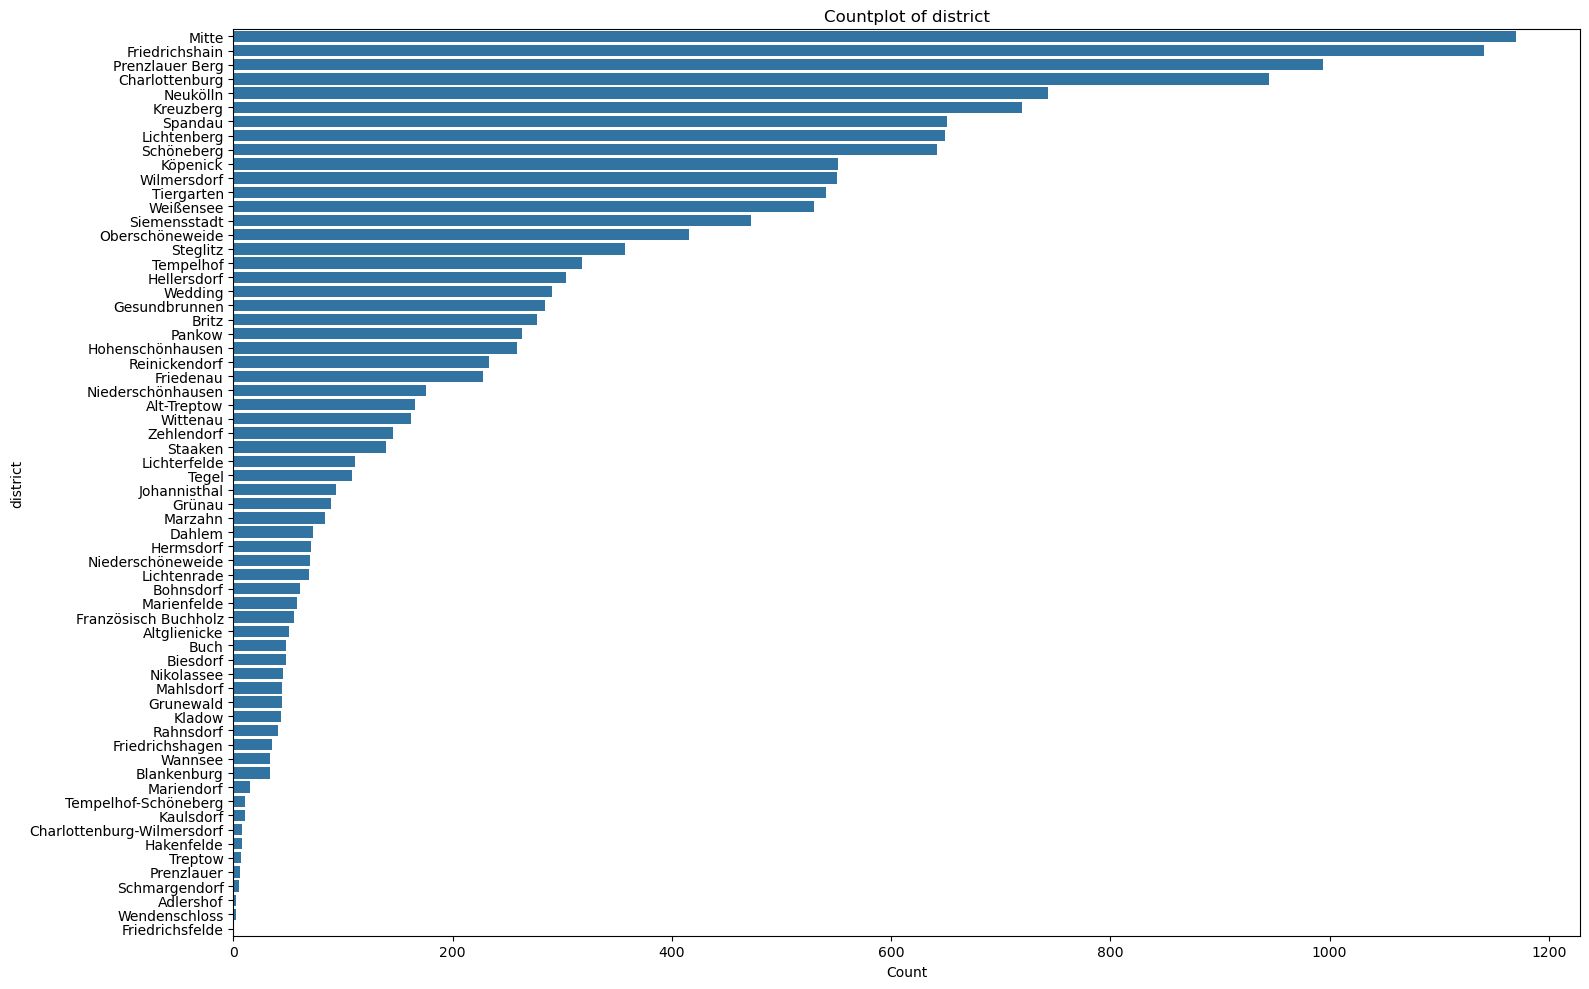

In [145]:
plt.figure(figsize=(16, 10))
sns.countplot(data=df, y="district", order=df["district"].value_counts().index)
plt.title('Countplot of district')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [146]:
# We have 'Prenzlauer Berg' written also as 'Prenzlauer', so we can just merge the categories together.
# df[df['district'] == 'Prenzlauer']['district']
df.loc[df['district'] == 'Prenzlauer','district'] = 'Prenzlauer Berg'

In [147]:
# We should also group categories with very few occuranes into more general districts to avoid too many categories.
df.loc[df['district'] == 'Friedrichsfelde','district'] = 'Lichtenberg'
df.loc[df['district'] == 'Wendenschloss','district'] = 'Köpenick'
df.loc[df['district'] == 'Adlershof','district'] = 'Köpenick'
df.loc[df['district'] == 'Schmargendorf','district'] = 'Wilmersdorf'
df.loc[df['district'] == 'Treptow','district'] = 'Köpenick'
df.loc[df['district'] == 'Hakenfelde','district'] = 'Spandau'
df.loc[df['district'] == 'Charlottenburg-Wilmersdorf','district'] = 'Charlottenburg'
df.loc[df['district'] == 'Kaulsdorf','district'] = 'Marzahn'
df.loc[df['district'] == 'Tempelhof-Schöneberg','district'] = 'Tempelhof'
df.loc[df['district'] == 'Mariendorf','district'] = 'Tempelhof'    # 15 values 

# As noticed some arbitrary decisions were made, like converting 'Tempelhof-Schöneberg' into 'Tempelhof'. I picked 'Tempelhof'
# instead of 'Schöneberg' to balance the categories more
# Also this impact is relevant since they were less than 15 samples.

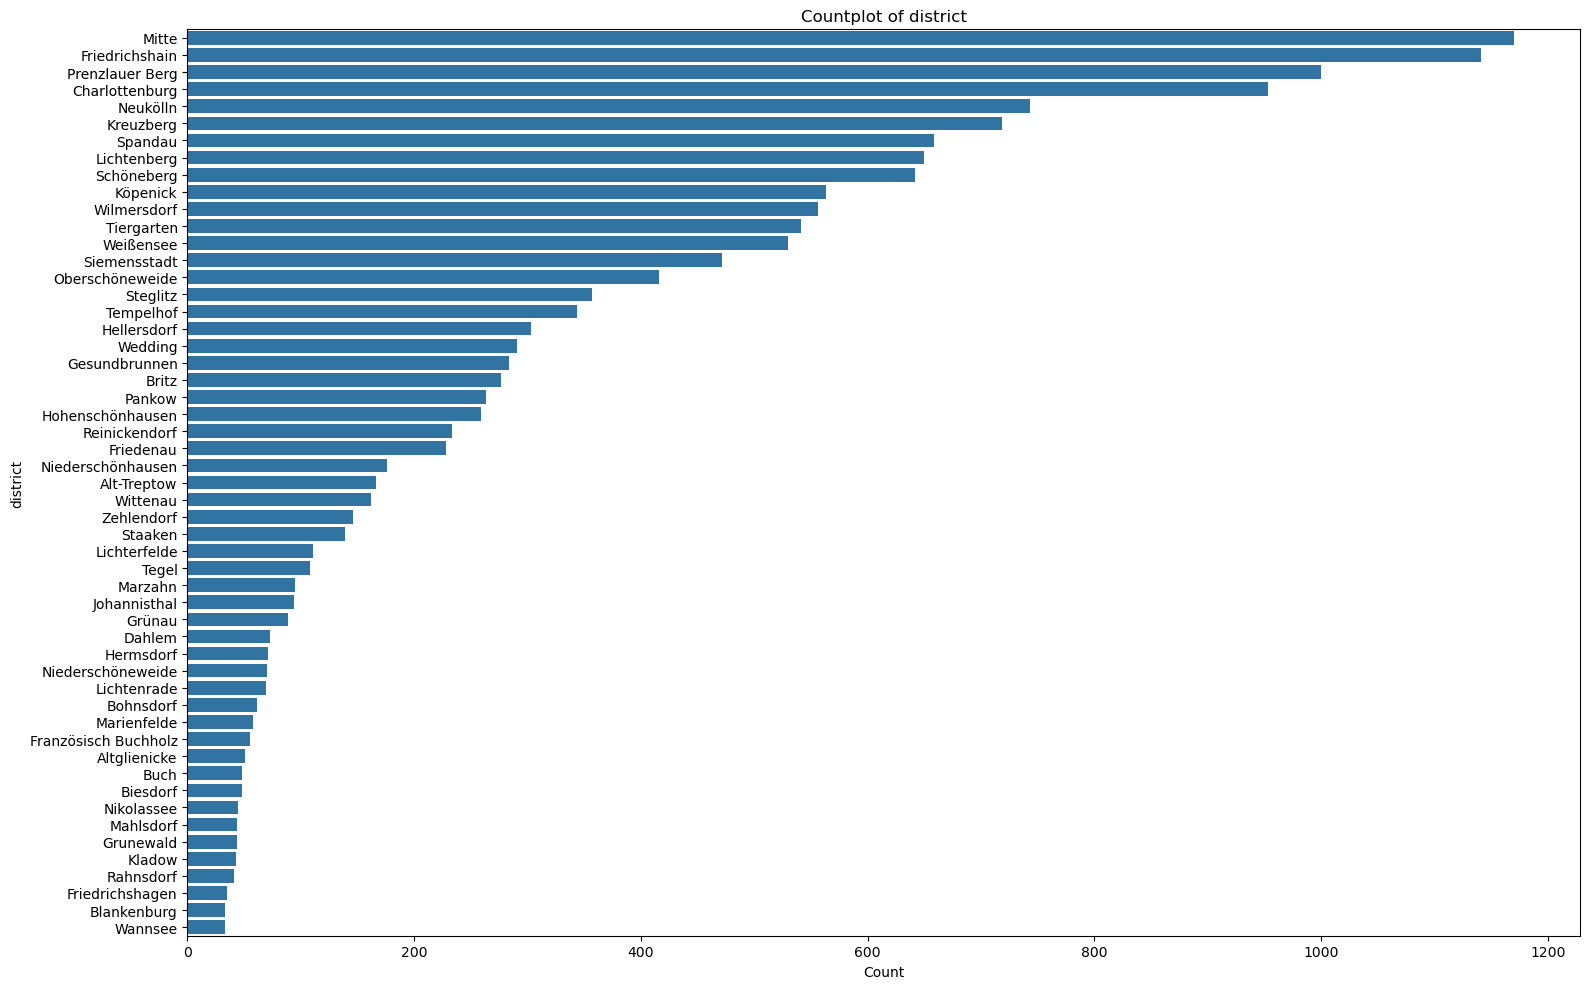

In [148]:
plt.figure(figsize=(16, 10))
sns.countplot(data=df, y="district", order=df["district"].value_counts().index)
plt.title('Countplot of district')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [149]:
len(df["district"].unique())

53

In [150]:
len(df[df["district"] == "Blankenburg"])

33

In [151]:
df.shape

(15802, 27)

<span style="font-weight:500">
The categories with the lowest number of samples are Wannsee and Blankenburg with 33 samples, which is not very low. We have 53 categories, which is quite a lot for a feature to have, but the type of the feature justifies it. I would prefer not to cluster any more categories together to preserve information. There are many ML models out there that work well with features with this many categories.
A ratio of 53 categories to 15,000 samples is also a good ratio.
</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 4: Handling outliers</span>

<span style="font-weight:500;color:#609926;font-size:15px">
1. Handling 'cold_rent' feature
</span>

In [152]:
df['cold_rent'].describe()

count    15802.00000
mean      1313.84175
std       1188.08090
min          1.09500
25%        677.50000
50%       1100.00000
75%       1642.00000
max      35000.00000
Name: cold_rent, dtype: float64

<span style="font-weight:500">
We clearly have outliers and a lot of them. We have to find a way to deal with them. But first we need to inspect them in detail to see whether they are a type or just an invalid sample.
</span>

In [153]:
# Knowing Berlin anything below 300 euros is not possible.
len(df[df['cold_rent'] < 300])

163

In [154]:
# We have to inspect at least 163 values. Every sample is valuable and should not be dropped, so will
# to inspect them one by one.
# We will start with a threshold of '2' and increase it gradually until we reach 300. 
df[df['cold_rent'] < 2]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at,location_clean,zip_code,district
28,https://www.immowelt.de/expose/ed2ff766-9412-4...,1.349,65.8,2.0,0.0,immediately,"Friedenauer Höhe 8, Friedenau, Berlin (12159)",True,False,False,...,unknown,District Heating,Underfloor Heating,Like New,2023,True,2025-12-28 21:33:00,"Friedenauer Höhe 8, Friedenau, (12159)",12159,Friedenau
26,https://www.immowelt.de/expose/7a4aec64-ab72-4...,1.449,66.5,2.0,0.0,not_immediately,"Friedenauer Höhe 10, Friedenau, Berlin (12159)",True,False,True,...,unknown,District Heating,Underfloor Heating,Like New,2023,True,2025-12-28 21:32:00,"Friedenauer Höhe 10, Friedenau, (12159)",12159,Friedenau
15,https://www.immowelt.de/expose/d4043120-352d-4...,1.095,45.0,2.0,0.0,immediately,"Kienhorststr. 103A, Reinickendorf, Berlin (13403)",True,True,True,...,Tiles,Heat Pump / Geothermal,Underfloor Heating,New / First Occupancy,2025,True,2025-12-28 21:30:00,"Kienhorststr. 103A, Reinickendorf, (13403)",13403,Reinickendorf
17,https://www.immowelt.de/expose/0d680cb5-7a9c-4...,1.595,67.5,2.0,0.0,immediately,"Kienhorststr. 103A, Reinickendorf, Berlin (13403)",False,False,True,...,Tiles,Heat Pump / Geothermal,Underfloor Heating,New / First Occupancy,2025,True,2025-12-28 21:30:00,"Kienhorststr. 103A, Reinickendorf, (13403)",13403,Reinickendorf
14,https://www.immowelt.de/expose/94b19a7d-b5d4-4...,1.095,40.0,2.0,0.0,immediately,"Kienhorststr. 103A, Reinickendorf, Berlin (13403)",True,False,True,...,Tiles,Heat Pump / Geothermal,Underfloor Heating,New / First Occupancy,2025,True,2025-12-28 21:29:00,"Kienhorststr. 103A, Reinickendorf, (13403)",13403,Reinickendorf
4,https://www.immowelt.de/expose/03a3d0b6-9fab-4...,1.399,65.8,2.0,-1.0,not_immediately,"Friedenauer Höhe 16, Friedenau, Berlin (12159)",True,False,False,...,unknown,District Heating,Underfloor Heating,Like New,2024,True,2025-12-28 21:27:00,"Friedenauer Höhe 16, Friedenau, (12159)",12159,Friedenau
0,https://www.immowelt.de/expose/f6e9dd76-dbe1-4...,1.499,58.3,2.0,-1.0,not_immediately,"Friedenauer Höhe 23a, Friedenau, Berlin (12159)",True,False,False,...,Wood,District Heating,Underfloor Heating,New / First Occupancy,2025,True,2025-12-28 21:25:00,"Friedenauer Höhe 23a, Friedenau, (12159)",12159,Friedenau
22169,https://www.immowelt.de/expose/f899bf21-d112-4...,1.250,80.0,3.0,NaN,unknown,"Mitte, Berlin (10115)",False,False,False,...,unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-31 16:33:37,"Mitte, (10115)",10115,Mitte
18694,https://www.immowelt.de/expose/f899bf21-d112-4...,1.250,80.0,3.0,6.0,unknown,"Mitte, Berlin (10115)",False,False,False,...,unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-27 21:15:53,"Mitte, (10115)",10115,Mitte
14493,https://www.immowelt.de/expose/f899bf21-d112-4...,1.250,80.0,3.0,4.0,unknown,"Mitte, Berlin (10115)",False,False,False,...,unknown,Unknown,Unknown,Unknown,<NA>,True,2026-01-23 10:44:24,"Mitte, (10115)",10115,Mitte


<span style="font-weight:500">
For this one the problem and solution are obvious, we just have to multiple the values by 1000. 
</span>

In [155]:
df.loc[df["cold_rent"] < 2, "cold_rent"] *= 1000

In [156]:
df[df['cold_rent'] < 5]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at,location_clean,zip_code,district
22,https://www.immowelt.de/expose/d5dbcc47-60a6-4...,2.300,115.0,3.0,0.0,unknown,"Rauschener Allee 4, Westend, Berlin (14055)",False,False,False,...,unknown,Heat Pump / Geothermal,Underfloor Heating,Renovated,1970,True,2025-12-28 21:31:00,"Rauschener Allee 4, Westend, (14055)",14055,Charlottenburg
18,https://www.immowelt.de/expose/94a3c69c-14a9-4...,2.040,88.6,3.0,0.0,immediately,"Heidestraße 39, Moabit, Berlin (10557)",True,False,False,...,unknown,District Heating,Underfloor Heating,New / First Occupancy,2024,True,2025-12-28 21:30:00,"Heidestraße 39, Moabit, (10557)",10557,Tiergarten
13,https://www.immowelt.de/expose/25d8e8ff-8de6-4...,2.110,87.8,3.0,0.0,immediately,"Heidestraße 39, Moabit, Berlin (10557)",True,False,False,...,unknown,District Heating,Underfloor Heating,New / First Occupancy,2024,True,2025-12-28 21:29:00,"Heidestraße 39, Moabit, (10557)",10557,Tiergarten
7,https://www.immowelt.de/expose/7e269628-a21a-4...,2.249,85.8,3.0,-1.0,not_immediately,"Friedenauer Höhe 24, Friedenau, Berlin (12159)",True,False,False,...,unknown,District Heating,Underfloor Heating,Like New,2023,True,2025-12-28 21:28:00,"Friedenauer Höhe 24, Friedenau, (12159)",12159,Friedenau
778,https://www.immowelt.de/expose/00aa6fd9-a5ab-4...,3.000,50.0,2.0,0.0,unknown,Berlin (13349),False,False,False,...,unknown,Unknown,Unknown,Unknown,<NA>,True,2025-12-29 00:05:18,(13349),13349,Wedding


In [157]:
# the last one looks weird I can't tell if it is 3000 or 300. Let's just inspect the listing if it is still available.
with pd.option_context('display.max_colwidth', None):
    print(df.loc[778]['listing_url'])

https://www.immowelt.de/expose/00aa6fd9-a5ab-4533-9d8f-f853047e4aa0?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D149#ln=classified_search_results&m=classified_search_results_classified_classified_detail_L


In [158]:
# even after inspecting the sample, I cannot tell and I don't want to risk making any arbitrary decision here so 
# I will simply delete the sample.
df = df.drop(index=778)

In [159]:
df.loc[df["cold_rent"] < 5, "cold_rent"] *= 1000

In [160]:
df[df['cold_rent'] < 5]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at,location_clean,zip_code,district


In [161]:
# Let's inspect the ones with small values
with pd.option_context('display.max_colwidth', None):
    print(df.loc[[11, 2]]['listing_url'])

11    https://www.immowelt.de/expose/2605b650-de83-4aeb-8bc8-bc8966e1d8a0?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
2     https://www.immowelt.de/expose/591c45d0-01dd-4baf-8f0b-626cf4b3d692?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
Name: listing_url, dtype: object


In [162]:
# Sample 11 was not available anymore, while sample 2 was available and it had the adjusted data this time.
df = df.drop(index=11)
df.loc[2, ["cold_rent", "floor"]] = [4100, 3]

In [163]:
with pd.option_context('display.max_colwidth', None):
    print(df[df['cold_rent'] < 200].sample(5)['listing_url'])

1713     https://www.immowelt.de/expose/af422439-0ca0-46dc-9f15-638e20af4eb3?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D91&feature_priceDropVariantB=true#ln=classified_search_results&m=classified_search_results_classified_classified_detail_XL
9384                                     https://www.immowelt.de/expose/932e5f77-56e1-4521-bd03-5859d065861b?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D73#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
10724                                    https://www.immowelt.de/expose/f7cd459a-1fd9-4003-91f7-791440ab5922?serp_view=list&search=distributionTypes%3DRent%26estateTypes%3DHouse%2CApartment%26locations%3DAD08DE8634%26page%3D96#ln=classified_search_results&m=classified_search_results_classified_classified_detail_M
744                                     https://www.imm

In [164]:
# They were all legit, they explicitly mentioned the price even in the description, so technically they were all legitimate. 
# But somehow there were some duplicates, which need to be removed.
df = df.drop(index=[10740, 1713, 1857])

In [165]:
# We know that 25% of the samples have a cold rent higher than 1642 and the maximum value is 35000.
df["cold_rent"].quantile([0.90, 0.95, 0.975, 0.985, 0.99, 0.995, 0.999])

0.900     2240.00
0.950     2700.00
0.975     3300.00
0.985     4750.00
0.990     6060.44
0.995     7175.00
0.999    12000.00
Name: cold_rent, dtype: float64

In [166]:
# Let's go with the 99% winsorization, since it only means removing 1% of about 16000 which is 160 samples
# Also these samples do not help our model in any way because it does not interest in our application. Also some of them were 
# just different floors of the same building. 
threshold = df["cold_rent"].quantile(0.99)
df = df[df["cold_rent"] <= threshold]

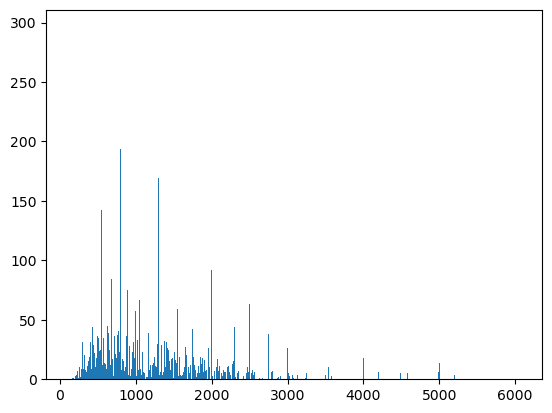

In [167]:
plt.hist(df['cold_rent'],bins=2000)
plt.show()

In [168]:
df["cold_rent"].quantile([0.90, 0.95, 0.975, 0.985, 0.99, 0.995, 0.999])

0.900    2200.000
0.950    2595.000
0.975    2990.000
0.985    3300.000
0.990    3762.000
0.995    4750.000
0.999    5416.422
Name: cold_rent, dtype: float64

In [169]:
# Now the percentiles are have more fair values and the graph of price distribution seems more fair. Before we move
# to the next feature let's just have one more look at the statistics of the prices.
df["cold_rent"].describe()

count    15639.000000
mean      1239.285980
std        743.418851
min        120.000000
25%        675.000000
50%       1100.000000
75%       1611.355000
max       6060.000000
Name: cold_rent, dtype: float64

<span style="font-weight:500;color:#609926;font-size:15px">
2. Handling 'area' feature
</span>

In [170]:
df["area"].describe()

count    15639.00000
mean        78.65274
std        117.60875
min          1.00000
25%         50.50000
50%         66.00000
75%         86.80000
max       5251.00000
Name: area, dtype: float64

In [171]:
# anything below 10 wouldn't make sense
df[df["area"] < 10]

,listing_url,cold_rent,area,rooms,floor,free_from,location,has_balkon,has_terrasse,has_garten,...,flooring_type,energy_source,heating_type,property_condition,year_built,schufa_check,scraped_at,location_clean,zip_code,district
12941,https://www.immowelt.de/expose/bf9188d4-e4b2-4...,2099.0,1.0,5.0,3.0,immediately,"Abendseglersteig 50, Wilhelmshagen, Berlin (12...",True,False,True,...,Wood,District Heating,Underfloor Heating,Like New,2021,True,2026-01-22 18:49:25,"Abendseglersteig 50, Wilhelmshagen, (12589)",12589,Rahnsdorf
5550,https://www.immowelt.de/expose/bf9188d4-e4b2-4...,2099.0,1.0,5.0,1.0,immediately,"Abendseglersteig 50, Wilhelmshagen, Berlin (12...",True,True,True,...,Wood,District Heating,Underfloor Heating,Like New,2021,True,2026-01-11 17:09:51,"Abendseglersteig 50, Wilhelmshagen, (12589)",12589,Rahnsdorf
4604,https://www.immowelt.de/expose/76343a42-0fc7-4...,2600.0,1.0,6.0,1.0,immediately,"Charlottenburg, Berlin (10623)",False,False,True,...,Wood,Unknown,Unit Heating,Renovated,1907,True,2026-01-11 14:05:05,"Charlottenburg, (10623)",10623,Charlottenburg
69,https://www.immowelt.de/expose/bf9188d4-e4b2-4...,2099.0,1.0,5.0,0.0,immediately,"Abendseglersteig 50, Wilhelmshagen, Berlin (12...",True,False,True,...,Wood,District Heating,Underfloor Heating,Like New,2021,True,2025-12-28 21:49:24,"Abendseglersteig 50, Wilhelmshagen, (12589)",12589,Rahnsdorf
1457,https://www.immowelt.de/expose/e29bc640-6917-4...,418.0,1.0,3.0,0.0,unknown,"Buch, Berlin (13125)",False,False,False,...,unknown,Unknown,Unknown,Unknown,<NA>,True,2025-12-31 17:20:53,"Buch, (13125)",13125,Buch


In [172]:
# These are all legitimate samples with legitimate valuse except area. Keeping them would confuse our model so we delete them.
df = df[df["area"] >= 10]

<span style="font-weight:500">
Since we decided to keep the luxury listings, we cannot remove anything from the higher tail. </span>

<span style="font-weight:500;color:#609926;font-size:15px">
3. Handling 'rooms' feature
</span>

In [173]:
df['rooms'].unique()

array([ 2. ,  1. ,  4. ,  5. ,  3. ,  1.5,  3.5,  8. ,  7. ,  2.5,  6. ,
        5.5,  4.5,  6.5, 10. ])

<span style="font-weight:500">
All of them are legitimate values. </span>

<span style="font-weight:500;color:#609926;font-size:15px">
4. Handling 'floor' feature
</span>

In [174]:
df['floor'].unique()

array([nan, 21., 20., 18., 17., 16., 15., 14., 13., 12., 11., 10.,  9.,
        8.,  7.,  6.,  5.,  4.,  3.,  2.,  1.,  0., -1.])

<span style="font-weight:500">
All of them are legitimate values.</span>

<span style="font-weight:500;color:#609926;font-size:15px">
5. Handling 'property_condition' feature
</span>

In [175]:
df['property_condition'].value_counts()

property_condition
Unknown                  9297
New / First Occupancy    1796
Like New                 1609
Well Maintained          1453
Renovated                1306
Old Building               56
Partially Renovated        44
Needs Renovation           38
Other                      35
Name: count, dtype: int64

<span style="font-weight:500">
Every category has its own meaning, so removing any of them would cause information loss. Removing the 'Other' category would cause 
losing valuable samples, so there is nothing we can adjust in this feature.
</span>

<span style="font-weight:500;color:#609926;font-size:15px">
6. Handling 'year_built' feature
</span>

In [176]:
df['year_built'].describe()

count         7688.0
mean     1996.926119
std        43.860206
min           1765.0
25%           1987.5
50%           2020.0
75%           2024.0
max           2026.0
Name: year_built, dtype: Float64

<span style="font-weight:500">
All of them are legitimate values.</span>

<span style="font-weight:500">
Now let's just remove the features that aren't needed and the dataset will be completely cleaned. </span>

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15634 entries, 22653 to 3
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   listing_url           15634 non-null  object        
 1   cold_rent             15634 non-null  float64       
 2   area                  15634 non-null  float64       
 3   rooms                 15634 non-null  float64       
 4   floor                 13686 non-null  float64       
 5   free_from             15634 non-null  object        
 6   location              15634 non-null  object        
 7   has_balkon            15634 non-null  boolean       
 8   has_terrasse          15634 non-null  boolean       
 9   has_garten            15634 non-null  boolean       
 10  elevator              15634 non-null  boolean       
 11  parking               15634 non-null  boolean       
 12  has_basement          15634 non-null  boolean       
 13  is_barrier-free      

In [178]:
df = df.drop(columns=["location","location_clean","scraped_at","zip_code"])

In [179]:
df.to_csv("../datasets/rent_listings.csv", encoding="utf-8-sig", index=False)